In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr
import xarray as xr
import sys

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
# from taylor_setup import *
from setup_diagnostic import *

In [2]:
# %% 1. Settings: four source regions and an expandable experiment inventory
import numpy as np
import xarray as xr
from pathlib import Path
from datetime import datetime, timezone

ra_core_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
ra_raw_dir = Path("/scratch/leiff/MCA/amip_clean/data")
ra_regional_path = ra_core_dir / "stationarity/regional/march_n178_regional.npy"
ra_run_dir = ra_core_dir / "stationarity/four_region_attribution/run_01"
ra_include_all_historical = False     # Later set True; existing physical members are reused.
ra_experiments = ["historical_matched", "amip_hist"]
if ra_include_all_historical:
    ra_experiments.append("historical")
ra_region_names = ["SEP", "SEPn", "SEPs", "WPWP"]
ra_split_latitude = None              # None = midpoint of archived SEP latitude rows (-20 on your grid).
ra_resume = True                      # Checked reuse by default, including after a kernel restart.
ra_save_monthly_indices = True        # A, Tg, Rg have (start_year,178) shape per member/region.
ra_confirmed_member_ids = None        # Optional {physical_experiment: {model: IDs in archive order}}.
ra_ddof, ra_min_windows = 1, 3
ra_save_figures = True
ra_plot_years = [1885,1890, 1980, 2000]
ra_plot_vlims = [1.5, .5, .35]         # D, cov_A_Zi, cov_Zi_R; identical for regions/years/groups.
ra_preprocessing_tag = "same_monthly_detrend_as_stationarity_v1"

# REQUIRED: import/paste YOUR detrend_monthly_fast before calculating.
# It removes climatology and month-specific linear trends within each March-
# start window. No high-pass filtering is used in this running-window branch.
# If you change that function/dependencies, change the preprocessing tag AND
# use a new run directory. Never run two writers against the same directory.
# Existing SEP notebooks/data remain untouched; this is a new archive schema.
# Load/plot only: run cells 1, 8, 9, then 10-12. No raw files are needed then.




In [3]:
# %% 2. Shared small helpers: protected saves, file alignment, means and fits
def ra_save_new(path, payload, *, replace=False):
    """Write fully to a temporary sibling file, then publish the finished bundle.

    Default refuses replacement. replace=True is only for regenerated model/
    MMM summaries and catalog during an explicit resume, not member outputs.
    """
    import os
    import tempfile
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and not replace:
        raise FileExistsError(path)
    temporary = None
    try:
        with tempfile.NamedTemporaryFile(dir=path.parent, prefix=f".{path.name}.", suffix=".tmp", delete=False) as handle:
            temporary = Path(handle.name)
            np.save(handle, payload, allow_pickle=True)
            handle.flush()
            os.fsync(handle.fileno())
        if replace:
            os.replace(temporary, path)
        else:
            os.link(temporary, path)  # Atomic publication; fails if the destination already exists.
    finally:
        if temporary is not None and temporary.exists():
            temporary.unlink()


def ra_mean_update(total, count, values):
    """Accumulate one member/model at a time; counts preserve missing support."""
    for key, value in values.items():
        value = np.asarray(value, dtype=float)
        if key not in total:
            total[key], count[key] = np.zeros_like(value), np.zeros(value.shape, dtype=np.int32)
        if total[key].shape != value.shape:
            raise ValueError(f"{key}: inconsistent shapes during aggregation.")
        finite = np.isfinite(value)
        total[key] += np.where(finite, value, 0.)
        count[key] += finite


def ra_mean_finish(total, count):
    return {key: np.divide(value, count[key], out=np.full_like(value, np.nan), where=count[key] > 0)
            for key, value in total.items()}


def ra_prepare_raw(field, months, lat, lon):
    """Validate dates/grid, then expose canonical (member,time,lat,lon) axes."""
    field = field.sel(time=slice(str(months[0]), str(months[-1])))
    actual = np.asarray(field.time.dt.year*12 + field.time.dt.month - 1)
    if not np.array_equal(actual, months.astype(int) + 1970*12):
        raise ValueError(f"{field.name}: missing, repeated, or reordered months.")
    for dimension, expected in [("lat", lat), ("lon", lon)]:
        actual = np.asarray(field[dimension])
        if actual.shape != expected.shape or not np.allclose(actual, expected, rtol=0, atol=1e-6):
            raise ValueError(f"{field.name}: {dimension} differs from the regional archive.")
    extra = [d for d in field.dims if d not in ["time", "lat", "lon"]]
    if len(extra) > 1:
        raise ValueError(f"Select extra dimensions explicitly: {field.dims}")
    if extra:
        dim = extra[0]
        ids = np.asarray(field[dim]).astype(str) if dim in field.coords else np.arange(field.sizes[dim]).astype(str)
        field = field.rename({dim: "member"}) if dim != "member" else field
        field = field.assign_coords(member=ids)
    else:
        field = field.expand_dims(member=["single"])
    if len(set(field.member.values.tolist())) != field.sizes["member"]:
        raise ValueError("Duplicate raw member labels.")
    return field.transpose("member", "time", "lat", "lon")


def ra_fit(index, response, min_windows=3):
    """Regress response(s,...) ON index(s); intercept included, no p-values.

    Counts are paired windows, NOT independent sample sizes. The standardized
    slope uses one index SD over all finite windows, not a cell-specific SD.
    """
    index, response = np.asarray(index, dtype=float), np.asarray(response, dtype=float)
    if index.ndim != 1 or response.shape[0] != len(index) or min_windows < 3:
        raise ValueError("Expected matching window axes and min_windows >= 3.")
    x = index.reshape((len(index),) + (1,)*(response.ndim - 1))
    paired = np.isfinite(x) & np.isfinite(response)
    n = paired.sum(axis=0)
    mx = np.divide(np.where(paired, x, 0.).sum(axis=0), n, out=np.zeros(response.shape[1:]), where=n > 0)
    my = np.divide(np.where(paired, response, 0.).sum(axis=0), n, out=np.zeros(response.shape[1:]), where=n > 0)
    dx, dy = np.where(paired, x, mx) - mx, np.where(paired, response, my) - my
    xx, yy, xy = np.sum(dx*dx, axis=0), np.sum(dy*dy, axis=0), np.sum(dx*dy, axis=0)
    varying_x = np.max(np.where(paired, x, -np.inf), axis=0) > np.min(np.where(paired, x, np.inf), axis=0)
    varying_y = np.max(np.where(paired, response, -np.inf), axis=0) > np.min(np.where(paired, response, np.inf), axis=0)
    fit_ok = (n >= min_windows) & varying_x & (xx > 0)
    xy = np.where(varying_y, xy, 0.)
    slope = np.divide(xy, xx, out=np.full_like(xx, np.nan), where=fit_ok)
    denominator = np.sqrt(xx)*np.sqrt(yy)
    corr = np.divide(xy, denominator, out=np.full_like(xx, np.nan), where=fit_ok & varying_y & (denominator > 0))
    finite_index = index[np.isfinite(index)]
    sd = float(np.std(finite_index, ddof=1)) if finite_index.size >= 2 else np.nan
    if finite_index.size and np.ptp(finite_index) == 0:
        sd = 0.
    return {"slope": slope, "corr": np.clip(corr, -1., 1.),
            "intercept": np.where(fit_ok, my - slope*mx, np.nan), "slope_per_index_sd": slope*sd}, n


def ra_check(left, right, label, rtol=1e-8, atol=1e-10):
    """A scientific closure/alignment check, with an error useful for inspection."""
    left, right = np.asarray(left), np.asarray(right)
    if left.shape != right.shape or not np.allclose(left, right, rtol=rtol, atol=atol, equal_nan=False):
        raise ValueError(f"Failed {label}; check preprocessing, support, dates and member alignment.")
    return float(np.max(np.abs(left - right)))


def ra_signature(settings):
    """Fingerprint numerical choices, not the list of experiment groups."""
    import hashlib
    import json
    def convert(value):
        if isinstance(value, np.ndarray):
            values = value.astype(str).tolist() if value.dtype.kind in "Mm" else value.tolist()
            return {"dtype": str(value.dtype), "values": values}
        if isinstance(value, np.generic):
            return value.item()
        raise TypeError(type(value))
    text = json.dumps(settings, default=convert, sort_keys=True, allow_nan=False, separators=(",", ":"))
    return hashlib.sha256(text.encode()).hexdigest()


def ra_quarantine(path, reason):
    """Preserve an incomplete output for inspection before recomputing it."""
    from uuid import uuid4
    backup = Path(path).with_name(f"{Path(path).name}.incomplete-{uuid4().hex[:12]}")
    Path(path).rename(backup)
    print(f"  Preserved incomplete {backup.name}: {reason}", flush=True)




In [4]:
# %% 3. Archived grid/windows and the exact SEP north/south partition
ra_regional = np.load(ra_regional_path, allow_pickle=True).item()  # Trusted files only.
ra_meta = ra_regional["metadata"]
ra_lat, ra_lon = [np.asarray(ra_meta[k], dtype=float) for k in ["lat", "lon"]]
ra_years = np.asarray(ra_meta["start_years"])
ra_starts, ra_ends = [np.asarray(ra_meta[k], dtype="datetime64[M]") for k in ["start_months", "end_months"]]
ra_length = int(ra_meta["window_months"])
if (ra_years.ndim != 1 or len(ra_years) < ra_min_windows or ra_length != 178 or ra_ddof != 1
        or ra_starts.shape != ra_years.shape or ra_ends.shape != ra_years.shape
        or np.any(np.diff(ra_years) != 1) or np.any(ra_starts.astype(int) % 12 != 2)
        or not np.array_equal(ra_starts.astype("datetime64[Y]").astype(int) + 1970, ra_years)
        or not np.array_equal(ra_ends, ra_starts + np.timedelta64(177, "M"))):
    raise ValueError("Expected consecutive March-start 178-month windows, with ddof=1.")
if any(v.ndim != 1 or not np.isfinite(v).all() for v in [ra_lat, ra_lon]):
    raise ValueError("Need finite 1-D lat/lon coordinates.")
ra_shape = (len(ra_lat), len(ra_lon))
ra_months = np.arange(ra_starts[0], ra_ends[-1] + np.timedelta64(1, "M"))
ra_window_starts = (ra_starts - ra_months[0]).astype(int)
ra_weights = np.ma.asarray(ra_meta["weights"], dtype=float).filled(np.nan)
if ra_weights.shape != ra_shape or np.any(ra_weights < 0):
    raise ValueError("Nonnegative area weights must match the grid.")
ra_weights = np.where(np.isfinite(ra_weights) & (ra_weights > 0), ra_weights, 0.)
if ra_weights.sum() <= 0:
    raise ValueError("No positive weights.")
ra_weights /= ra_weights.sum()
ra_support = ra_weights > 0
ra_regions = {}
for name in ["SEP", "WPWP"]:
    mask = np.ma.asarray(ra_regional["regions"][name], dtype=float).filled(np.nan)
    if mask.shape != ra_shape:
        raise ValueError(f"{name}: archived mask shape differs from the grid.")
    ra_regions[name] = np.isfinite(mask) & (mask != 0) & ra_support
    if not ra_regions[name].any():
        raise ValueError(f"{name}: empty region.")

# Keep the original trapezoid's cells, including its sloping eastern boundary.
# This is a latitude-midpoint split, NOT an equal-area split. Any cell centered
# exactly on the split belongs to the north, so there is no gap/double counting.
sep_rows = ra_lat[np.any(ra_regions["SEP"], axis=1)]
ra_split = float((sep_rows.min() + sep_rows.max())/2 if ra_split_latitude is None else ra_split_latitude)
ra_regions["SEPn"] = ra_regions["SEP"] & (ra_lat[:, None] >= ra_split)
ra_regions["SEPs"] = ra_regions["SEP"] & (ra_lat[:, None] < ra_split)
ra_regions = {name: ra_regions[name] for name in ra_region_names}
if not np.isfinite(ra_split) or any(not mask.any() for mask in ra_regions.values()):
    raise ValueError("The split must leave nonempty north and south masks.")
if np.any(ra_regions["SEPn"] & ra_regions["SEPs"]) or not np.array_equal(ra_regions["SEPn"] | ra_regions["SEPs"], ra_regions["SEP"]):
    raise ValueError("North/south must partition the original SEP exactly.")
ra_region_area = {r: float(ra_weights[mask].sum()) for r, mask in ra_regions.items()}
ra_sep_fractions = {r: ra_region_area[r]/ra_region_area["SEP"] for r in ["SEPn", "SEPs"]}
print(f"SEP split latitude: {ra_split:g}; fractions of SEP area: {ra_sep_fractions}")
print(f"Windows: March {ra_years[0]} through March {ra_years[-1]}, {ra_length} months each")




SEP split latitude: -20; fractions of SEP area: {'SEPn': 0.4993177926788023, 'SEPs': 0.5006822073211981}
Windows: March 1870 through March 2000, 178 months each


In [5]:
# %% 4. Diagnostic registry and the calculation for ONE window and ALL needed regions
# Local-temperature projection/residual maps and series are intentionally absent.
# cov_Zi_Ri and the diagonal/cross-cell budgets remain: those are different,
# directly measurable covariance diagnostics, not the discarded projection.
ra_map_definitions = {
    "D": ("W m-2", "Cov(A,Rj): radiation-origin map for this source region"),
    "cov_A_Zi": ("1", "Cov(A,Zi): SEP/region temperature co-variability"),
    "cov_A_Ti": ("K", "Cov(A,Ti): temperature co-variability retaining local SD"),
    "cov_A_Qi": ("1", "Cov(A,Qi): radiation co-variability without local radiation SD"),
    "corr_A_Ti": ("1", "Within-window monthly correlation of A and local T"),
    "corr_A_Ri": ("1", "Within-window monthly correlation of A and local R"),
    "cov_Zi_Ri": ("W m-2", "Local Cov(Zi,Ri); not a projection component"),
    "sigma_Ti": ("K", "Within-window detrended local T SD"),
    "sigma_Ri": ("W m-2", "Within-window detrended local R SD"),
    "cov_Zi_T": ("K", "Cov(Zi,T_global)"),
    "cov_Qi_R": ("W m-2", "Cov(Qi,R_global)"),
    "cov_Zi_R": ("W m-2", "Cov(Zi,R_global); independent of the chosen source region"),
}
ra_series_definitions = {
    "I": ("W m-2", "Area mean of cov_Zi_R WITHIN this region = Cov(A,R_global)"),
    "I_inside": ("W m-2", "Global-weighted D integral inside the selected source region"),
    "I_outside": ("W m-2", "Global-weighted D integral outside the selected source region"),
    "I_diag": ("W m-2", "Same-grid-cell contribution sum_region(p_i*w_i*Cov(Zi,Ri))"),
    "I_inside_cross": ("W m-2", "Within-region cross-cell contribution: I_inside-I_diag"),
    "local_diag_mean": ("W m-2", "Regional mean of cov_Zi_Ri; NOT a global budget contribution"),
    "sigma_A": ("1", "Monthly SD of the regional mean of standardized temperatures"),
    "sigma_T": ("K", "Monthly global T SD"),
    "sigma_R": ("W m-2", "Monthly global R SD"),
    "I_outside_SEP": ("W m-2", "D integral outside the ORIGINAL full SEP, for this source index"),
}
# These extra receiving-region budgets distinguish radiation in the OTHER half
# of SEP from radiation outside SEP entirely. SEP overlaps its two children;
# never sum all four receiving-region budgets as though they were disjoint.
for region in ra_region_names:
    ra_series_definitions[f"I_in_{region}"] = ("W m-2", f"Global-weighted D integral within receiving region {region}")
ra_quantity_info = {}
for kind, definitions in [("running_map", ra_map_definitions), ("series", ra_series_definitions)]:
    dims = ("start_year", "lat", "lon") if kind == "running_map" else ("start_year",)
    for key, (units, meaning) in definitions.items():
        ra_quantity_info[key] = {"kind": kind, "dims": dims, "units": units, "meaning": meaning}
ra_fit_quantities = list(ra_quantity_info)
for key in ra_fit_quantities:
    info = ra_quantity_info[key]
    for statistic in ["slope", "corr", "intercept", "slope_per_index_sd"]:
        units = "1" if statistic == "corr" else f"({info['units']})/(W m-2)" if statistic == "slope" else info["units"]
        ra_quantity_info[f"{statistic}_{key}"] = {"kind": "map" if info["kind"] == "running_map" else "scalar",
            "dims": info["dims"][1:], "units": units, "meaning": f"Across-window {statistic} of {key} ON this region/member's I"}
if ra_save_monthly_indices:
    for key, units in [("A", "1"), ("Tg", "K"), ("Rg", "W m-2")]:
        ra_quantity_info[key] = {"kind": "window_monthly", "dims": ("start_year", "month_in_window"),
                                  "units": units, "meaning": f"Processed monthly {key}; A is NOT standardized a second time"}
ra_sizes = {"start_year": len(ra_years), "lat": len(ra_lat), "lon": len(ra_lon), "month_in_window": ra_length}


def ra_one_window(raw_T, raw_R, weights, regions, requested, preprocess, ddof=1):
    """Preprocess this window ONCE; reuse the fields for each requested source."""
    support = weights > 0
    fields = []
    for raw in [raw_T, raw_R]:
        raw = np.asarray(raw, dtype=float)
        if raw.ndim != 3 or raw.shape[1:] != weights.shape or not np.isfinite(raw[:, support]).all():
            raise ValueError("Need complete monthly fields on the fixed weighted domain.")
        # Fresh arrays protect raw windows from an in-place user function.
        field = np.asarray(preprocess(np.where(support[None], raw, 0.)), dtype=float)
        if field.shape != raw.shape or not np.isfinite(field[:, support]).all():
            raise ValueError("Invalid detrend_monthly_fast output.")
        fields.append(np.where(support[None], field-field.mean(axis=0), 0.))
    Ti, Ri = fields
    n = len(Ti)
    if len(Ri) != n or n <= ddof:
        raise ValueError("Inconsistent or insufficient time samples.")
    cov = lambda a, b: np.sum(a*b, axis=0)/(n-ddof)
    sigma_Ti, sigma_Ri = [np.where(np.ptp(v, axis=0) > 0, np.std(v, axis=0, ddof=ddof), 0.) for v in fields]
    variable_T, variable_R = support & (sigma_Ti > 0), support & (sigma_Ri > 0)
    Zi = np.divide(Ti, sigma_Ti, out=np.zeros_like(Ti), where=variable_T)
    Qi = np.divide(Ri, sigma_Ri, out=np.zeros_like(Ri), where=variable_R)
    Tg, Rg = [np.einsum("tij,ij->t", v, weights) for v in fields]
    B = cov(Zi, Ri)
    common = {"cov_Zi_Ri": np.where(variable_T, B, np.nan), "sigma_Ti": sigma_Ti, "sigma_Ri": sigma_Ri,
              "cov_Zi_T": np.where(variable_T, cov(Zi, Tg[:, None, None]), np.nan),
              "cov_Qi_R": np.where(variable_R, cov(Qi, Rg[:, None, None]), np.nan),
              "cov_Zi_R": np.where(variable_T, cov(Zi, Rg[:, None, None]), np.nan)}
    result = {}
    for name in requested:
        mask = regions[name]
        if not variable_T[mask].all():
            raise ValueError(f"{name}: a source cell has zero T variance, so its Zi is undefined.")
        p = np.where(mask, weights, 0.)
        p /= p.sum()
        A = np.einsum("tij,ij->t", Zi, p)
        a = A[:, None, None]
        sigma_A = float(np.std(A, ddof=ddof)) if np.ptp(A) > 0 else 0.
        D, C, E = cov(a, Ri), cov(a, Zi), cov(a, Qi)
        corr_T = np.divide(C, sigma_A, out=np.full_like(C, np.nan), where=variable_T & (sigma_A > 0))
        corr_R = np.divide(E, sigma_A, out=np.full_like(E, np.nan), where=variable_R & (sigma_A > 0))
        maps = common | {"D": D, "cov_A_Zi": np.where(variable_T, C, np.nan), "cov_A_Ti": cov(a, Ti),
                         "cov_A_Qi": np.where(variable_R, E, np.nan),
                         "corr_A_Ti": np.clip(corr_T, -1., 1.), "corr_A_Ri": np.clip(corr_R, -1., 1.)}
        values = {q: np.where(support, v, np.nan) for q, v in maps.items()}
        I, inside = cov(A, Rg), np.sum(weights[mask]*D[mask])
        outside = np.sum(weights[support & ~mask]*D[support & ~mask])
        diagonal = np.sum(p[mask]*weights[mask]*B[mask])
        receiving = {f"I_in_{r}": np.sum(weights[m]*D[m]) for r, m in regions.items()}
        values.update({"I": I, "I_inside": inside, "I_outside": outside, "I_diag": diagonal,
            "I_inside_cross": inside-diagonal, "local_diag_mean": np.sum(p[mask]*B[mask]),
            "sigma_A": sigma_A, "sigma_T": np.std(Tg, ddof=ddof), "sigma_R": np.std(Rg, ddof=ddof),
            "I_outside_SEP": np.sum(weights[support & ~regions['SEP']]*D[support & ~regions['SEP']]), **receiving})
        checks = {"global_D": ra_check(np.sum(weights*D), I, "global D=I"),
                  "regional_index": ra_check(np.sum(p[mask]*common["cov_Zi_R"][mask]), I, "regional cov_Zi_R=I"),
                  "inside_outside": ra_check(inside+outside, I, "inside+outside=I"),
                  "receiving_SEP": ra_check(receiving["I_in_SEPn"]+receiving["I_in_SEPs"], receiving["I_in_SEP"], "receiving SEP halves"),
                  "radiation_amplitude": ra_check((sigma_Ri*E)[support], D[support], "sigma_Ri*cov_A_Qi=D")}
        result[name] = (values, {"A": A, "Tg": Tg, "Rg": Rg}, checks)
    if {"SEP", "SEPn", "SEPs"} <= set(result):
        fractions = {r: weights[regions[r]].sum()/weights[regions["SEP"]].sum() for r in ["SEPn", "SEPs"]}
        mixed_D = sum(fractions[r]*result[r][0]["D"][support] for r in fractions)
        mixed_A = sum(fractions[r]*result[r][1]["A"] for r in fractions)
        result["SEP"][2]["source_mix_D"] = ra_check(mixed_D, result["SEP"][0]["D"][support], "north/south radiation-map mixture")
        result["SEP"][2]["source_mix_A"] = ra_check(mixed_A, result["SEP"][1]["A"], "north/south monthly index mixture")
    return result




In [6]:
# %% 5. Checkpoint validation and run identity (experiments can be added safely)
def ra_validate_budget(values, region, reference=None):
    """Use unnormalized receiving-area weights; only the source index is normalized."""
    mask, support = ra_regions[region], ra_support
    p = ra_weights[mask]/ra_weights[mask].sum()
    ra_check(np.sum(values["D"][..., support]*ra_weights[support], axis=-1), values["I"], "saved global D=I")
    ra_check(np.sum(values["cov_Zi_R"][..., mask]*p, axis=-1), values["I"], "saved regional cov_Zi_R=I")
    ra_check(values["I_inside"]+values["I_outside"], values["I"], "saved inside/outside")
    ra_check(values["I_diag"]+values["I_inside_cross"], values["I_inside"], "saved within-region cross cells")
    ra_check(values["I_in_SEPn"]+values["I_in_SEPs"], values["I_in_SEP"], "saved receiving halves")
    ra_check(values["I_in_SEP"]+values["I_outside_SEP"], values["I"], "saved full-SEP complement")
    if reference is not None:
        ra_check(values["I"], reference, f"{region}: original archived regional index")


def ra_load_member(path, region, label, raw_id, sources, reference=None):
    """Return complete compatible output, or preserve incomplete output and redo."""
    import pickle
    path = Path(path)
    if not path.exists():
        return None
    try:
        saved = np.load(path, allow_pickle=True).item()
    except (ValueError, EOFError, pickle.UnpicklingError) as error:
        ra_quarantine(path, type(error).__name__)
        return None
    required = {"values", "fit_n_windows", "closure_max_abs_error", "member_label", "raw_member_id", "sources", "signature", "region"}
    if not isinstance(saved, dict) or not required <= saved.keys():
        ra_quarantine(path, "missing checkpoint content")
        return None
    if (saved["signature"] != ra_run_signature or saved["region"] != region or str(saved["member_label"]) != str(label)
            or saved["raw_member_id"] != str(raw_id) or saved["sources"] != sources):
        raise ValueError(f"{path}: settings, identity or raw source changed. Use a new directory or the original settings.")
    v = saved["values"]
    if not isinstance(v, dict) or set(v) != set(ra_quantity_info) or set(saved["fit_n_windows"]) != set(ra_fit_quantities):
        ra_quarantine(path, "missing diagnostic values/counts")
        return None
    for key, info in ra_quantity_info.items():
        value = np.asarray(v[key])
        if value.shape != tuple(ra_sizes[d] for d in info["dims"]) or value.dtype.kind not in "fiu" or np.isinf(value).any():
            ra_quarantine(path, f"invalid {key}")
            return None
    for key in ["D", "sigma_Ti", "sigma_Ri"]:
        if not np.isfinite(v[key][..., ra_support]).all():
            ra_quarantine(path, f"missing finite {key}")
            return None
    for key in ra_fit_quantities:
        if ra_quantity_info[key]["kind"] == "series" and not np.isfinite(v[key]).all():
            ra_quarantine(path, f"missing windows for {key}")
            return None
        n = np.asarray(saved["fit_n_windows"][key])
        expected = np.isfinite(v[key]).sum(axis=0)
        if n.shape != expected.shape or not np.array_equal(n, expected):
            ra_quarantine(path, f"invalid fit sample counts for {key}")
            return None
    ra_validate_budget(v, region, reference)
    return saved


def ra_summarize(paths, destination, *, level, region, labels):
    """Mean one child bundle at a time; unchanged summaries are reused too."""
    import pickle
    tokens = [{"path": str(p.relative_to(ra_run_dir)), "size": p.stat().st_size, "mtime_ns": p.stat().st_mtime_ns} for p in paths]
    signature = ra_signature({"run": ra_run_signature, "children": tokens, "level": level, "region": region, "labels": list(labels)})
    if destination.exists():
        try:
            old = np.load(destination, allow_pickle=True).item()
            valid = (old["summary_signature"] == signature and set(old["values"]) == set(ra_quantity_info)
                     and set(old["n_valid"]) == set(ra_quantity_info))
            for key, info in ra_quantity_info.items():
                shape = tuple(ra_sizes[d] for d in info["dims"])
                valid = valid and np.shape(old["values"][key]) == shape and np.shape(old["n_valid"][key]) == shape
            if valid:
                ra_validate_budget(old["values"], region)
                return old
        except (ValueError, EOFError, KeyError, TypeError, pickle.UnpicklingError):
            pass  # This derived summary can be rebuilt from validated children.
    totals, counts = {}, {}
    for path in paths:
        child = np.load(path, allow_pickle=True).item()
        ra_mean_update(totals, counts, child["values"])
        del child
    values = ra_mean_finish(totals, counts)
    ra_validate_budget(values, region)
    result = {"values": values, "n_valid": counts, "summary_signature": signature,
              "region": region, "level": level, "labels": list(labels), "n_children": len(paths)}
    ra_save_new(destination, result, replace=destination.exists())
    return result


if not callable(globals().get("detrend_monthly_fast")):
    raise NameError("Import/paste your detrend_monthly_fast before calculating.")
if ra_run_dir.exists() and not ra_resume:
    raise FileExistsError("Choose a new directory or enable checked reuse with ra_resume=True.")
ra_run_dir.mkdir(parents=True, exist_ok=ra_resume)
import inspect
try:
    ra_preprocessing_source = inspect.getsource(detrend_monthly_fast)
except (OSError, TypeError):
    ra_preprocessing_source = "Source unavailable; keep the preprocessing function/tag unchanged."
ra_coordinates = {"lat": ra_lat, "lon": ra_lon, "start_year": ra_years, "start_month": ra_starts,
                  "end_month": ra_ends, "month_in_window": np.arange(ra_length)}
ra_settings = {"schema": "four_region_running_v1", "coordinates": ra_coordinates, "weights": ra_weights,
               "regions": ra_regions, "split_latitude": ra_split, "ddof": ra_ddof, "min_windows": ra_min_windows,
               "quantity_info": ra_quantity_info, "preprocessing_source": ra_preprocessing_source, "preprocessing_tag": ra_preprocessing_tag}
ra_run_signature = ra_signature(ra_settings)
settings_path = ra_run_dir/"run_settings.npy"
if settings_path.exists():
    previous = np.load(settings_path, allow_pickle=True).item()
    if previous["signature"] != ra_run_signature:
        raise ValueError("Numerical settings changed. Use a new run directory; adding experiments alone is allowed.")
else:
    ra_save_new(settings_path, {"signature": ra_run_signature, "settings": ra_settings})

# Do not remove earlier groups from the catalog when the flag is later False.
# Experiments select populations, not numerical settings, so adding historical
# never invalidates existing historical_matched/amip member checkpoints.
ra_previous_catalog = None
if (ra_run_dir/"catalog.npy").exists():
    import pickle
    try:
        ra_previous_catalog = np.load(ra_run_dir/"catalog.npy", allow_pickle=True).item()
    except (ValueError, EOFError, pickle.UnpicklingError):
        ra_quarantine(ra_run_dir/"catalog.npy", "unreadable catalog; rebuilding from checkpoints")
    if ra_previous_catalog is not None and ra_previous_catalog["signature"] != ra_run_signature:
        raise ValueError("Existing catalog belongs to different numerical settings.")
ra_available_experiments = list(ra_experiments)
if ra_previous_catalog is not None:
    ra_available_experiments += [e for e in ra_previous_catalog["model_names"] if e not in ra_available_experiments]
if not ra_available_experiments or not set(ra_available_experiments) <= {"historical", "historical_matched", "amip_hist"}:
    raise ValueError("Choose the supported experiment groups.")
ra_models = {e: list(ra_meta["model_names"][e]) for e in ra_available_experiments}
if set(ra_meta["model_names"]["historical_matched"]) != set(ra_meta["model_names"]["historical"]) & set(ra_meta["model_names"]["amip_hist"]):
    raise ValueError("Matched historical must be the historical/AMIP intersection.")
ra_jobs = {}
for experiment, models in ra_models.items():
    if not models or len(models) != len(set(models)):
        raise ValueError(f"{experiment}: missing/duplicate model names.")
    if ra_previous_catalog is not None and experiment in ra_previous_catalog["model_names"]:
        if models != ra_previous_catalog["model_names"][experiment]:
            raise ValueError("An existing group's model population/order changed. Use a new directory.")
    for model in models:
        physical = "amip_hist" if experiment == "amip_hist" else "historical"
        ra_jobs.setdefault((physical, model), []).append(experiment)
ra_manifest = {"signature": ra_run_signature, "coordinates": ra_coordinates, "quantity_info": ra_quantity_info,
    "weights": ra_weights, "regions": ra_regions, "region_area": ra_region_area, "SEP_area_fractions": ra_sep_fractions,
    "model_names": ra_models, "member_labels": {e: {} for e in ra_models},
    "member_files": {r: {e: {} for e in ra_models} for r in ra_region_names},
    "model_files": {r: {e: {} for e in ra_models} for r in ra_region_names},
    "MMM_files": {r: {} for r in ra_region_names},
    "metadata": {"created_utc": datetime.now(timezone.utc).isoformat(), "split_latitude": ra_split,
        "regional_source": str(ra_regional_path), "settings": ra_settings,
        "aggregation": "Member diagnostics then arithmetic member means then equal-model MMM; not pooled moments",
        "fits": "Across-window OLS with intercept ON the same source-region/member I; no p-values",
        "interpretation": "Geographic covariance contributions, not causal local/remote feedback attribution"}}
ra_complete = False




In [7]:
# %% 6. Member checkpoints: one window preprocessing shared by all missing regions
for (physical, model), aliases in ra_jobs.items():
    print(f"{physical} / {model}", flush=True)
    labels = np.asarray(ra_meta["member_labels"][aliases[0]][model])
    if labels.ndim != 1 or not len(labels) or len(set(labels.tolist())) != len(labels):
        raise ValueError(f"{model}: invalid archived member labels.")
    for alias in aliases:
        if not np.array_equal(labels, ra_meta["member_labels"][alias][model]):
            raise ValueError(f"{model}: historical aliases disagree on member order.")
        if ra_previous_catalog is not None and alias in ra_previous_catalog["member_labels"]:
            if not np.array_equal(labels, ra_previous_catalog["member_labels"][alias][model]):
                raise ValueError(f"{model}: existing catalog member order changed.")
        ra_manifest["member_labels"][alias][model] = labels.copy()
    references = {}
    for region in ra_region_names:
        for alias in aliases:
            original = ra_regional["member_values"][alias].get("cov_Zi_R", {}).get(region, {}).get(model)
            if original is not None:
                original = np.asarray(original, dtype=float)
                if original.shape != (len(labels), len(ra_years)) or not np.isfinite(original).all():
                    raise ValueError(f"{alias}/{model}/{region}: invalid archived reference index.")
                if region in references:
                    ra_check(original, references[region], "original reference indices for historical aliases")
                references[region] = original
    folder, tag = ("AMIP", "amip-hist") if physical == "amip_hist" else ("HIST", "historical")
    paths = {}
    for variable in ["tas", "N"]:
        candidates = sorted((ra_raw_dir/folder/model).glob(f"{variable}_Amon_{model}_*{tag}*combined*187001-201412_g025.nc"))
        if len(candidates) != 1:
            raise ValueError(f"{model}/{variable}: expected one combined file, found {candidates}")
        paths[variable] = candidates[0]
    sources = {v: {"path": str(p), "size_bytes": p.stat().st_size, "mtime_ns": p.stat().st_mtime_ns} for v, p in paths.items()}
    model_member_paths = {r: [] for r in ra_region_names}
    with xr.open_dataset(paths["tas"]) as ds_T, xr.open_dataset(paths["N"]) as ds_R:
        fields = {"tas": ra_prepare_raw(ds_T["tas"], ra_months, ra_lat, ra_lon), "N": ra_prepare_raw(ds_R["N"], ra_months, ra_lat, ra_lon)}
        ids = None if ra_confirmed_member_ids is None else np.asarray(ra_confirmed_member_ids[physical][model]).astype(str)
        if ids is None and ra_meta.get("member_label_kind") == "user-confirmed member IDs":
            ids = labels.astype(str)
        if ids is not None:
            if ids.shape != labels.shape or len(set(ids.tolist())) != len(labels):
                raise ValueError("Confirmed IDs must match archived member order and count.")
            fields = {v: field.sel(member=ids) for v, field in fields.items()}
        if any(field.sizes["member"] != len(labels) for field in fields.values()) or not np.array_equal(fields["tas"].member, fields["N"].member):
            raise ValueError(f"{model}: raw member order/count differs. Supply confirmed IDs.")
        sources["alignment"] = "confirmed IDs" if ids is not None else "assumed file positions; available original indices checked"
        allowed_units = {"tas": {"K", "kelvin", "Kelvin"}, "N": {"W m-2", "W m^-2", "W m**-2", "W/m2", "W/m^2", "W m−2"}}
        for v, field in fields.items():
            unit = field.attrs.get("units")
            if unit is not None and unit not in allowed_units[v]:
                raise ValueError(f"{v}: convert units {unit!r} explicitly.")
            sources[v]["units"] = unit or "Missing: assuming K for tas, W m-2 for N"

        for member, label in enumerate(labels):
            raw_id = str(fields["tas"].member.values[member])
            missing, selected_paths = [], {}
            for region in ra_region_names:
                path = Path("members")/physical/model/f"member_{member:03d}_{region}.npy"
                model_member_paths[region].append(str(path))
                selected_paths[region] = path
                reference = references[region][member] if region in references else None
                saved = ra_load_member(ra_run_dir/path, region, label, raw_id, sources, reference) if ra_resume else None
                if saved is None:
                    missing.append(region)
                del saved
            if not missing:
                print(f"  member {member+1}: all four regions checked/reused; no window calculations", flush=True)
                continue
            print(f"  member {member+1}: calculate {', '.join(missing)}", flush=True)
            # At the native grid these buffers are about 0.5 GiB for all four
            # regions. Means are streamed later, not held for all models here.
            collected = {r: {q: np.full(tuple(ra_sizes[d] for d in info["dims"]), np.nan)
                for q, info in ra_quantity_info.items() if q in ra_fit_quantities or info["kind"] == "window_monthly"} for r in missing}
            errors = {r: {} for r in missing}
            raw_T, raw_R = [np.asarray(fields[v].isel(member=member).values, dtype=float) for v in ["tas", "N"]]
            for s, start in enumerate(ra_window_starts):
                window = slice(start, start+ra_length)
                results = ra_one_window(raw_T[window], raw_R[window], ra_weights, ra_regions, missing, detrend_monthly_fast, ra_ddof)
                for region, (values, monthly, checks) in results.items():
                    for key in ra_fit_quantities:
                        collected[region][key][s] = values[key]
                    if ra_save_monthly_indices:
                        for key, value in monthly.items():
                            collected[region][key][s] = value
                    for key, value in checks.items():
                        errors[region][key] = max(errors[region].get(key, 0.), value)
            del raw_T, raw_R, results
            for region in missing:
                values = collected.pop(region)
                reference = references[region][member] if region in references else None
                ra_validate_budget(values, region, reference)
                fit_n = {}
                for key in ra_fit_quantities:
                    fitted, fit_n[key] = ra_fit(values["I"], values[key], ra_min_windows)
                    values.update({f"{stat}_{key}": v for stat, v in fitted.items()})
                if np.ptp(values["I"]) > 0:
                    errors[region]["slope_global"] = ra_check(np.sum(ra_weights[ra_support]*values["slope_D"][ra_support]), np.asarray(1.), "global slope_D=1")
                    errors[region]["slope_inside_outside"] = ra_check(values["slope_I_inside"]+values["slope_I_outside"], np.asarray(1.), "component slopes=1")
                bundle = {"values": values, "fit_n_windows": fit_n, "closure_max_abs_error": errors[region],
                    "member_label": label, "raw_member_id": raw_id, "sources": sources, "signature": ra_run_signature, "region": region}
                ra_save_new(ra_run_dir/selected_paths[region], bundle)
                del values, bundle
    for region in ra_region_names:
        for alias in aliases:
            ra_manifest["member_files"][region][alias][model] = model_member_paths[region].copy()




historical / BCC-CSM2-MR
  member 1: calculate SEP, SEPn, SEPs, WPWP
  member 2: calculate SEP, SEPn, SEPs, WPWP
  member 3: calculate SEP, SEPn, SEPs, WPWP
historical / CAMS-CSM1-0
  member 1: calculate SEP, SEPn, SEPs, WPWP
  member 2: calculate SEP, SEPn, SEPs, WPWP
  member 3: calculate SEP, SEPn, SEPs, WPWP
historical / CESM2
  member 1: calculate SEP, SEPn, SEPs, WPWP
  member 2: calculate SEP, SEPn, SEPs, WPWP
  member 3: calculate SEP, SEPn, SEPs, WPWP
  member 4: calculate SEP, SEPn, SEPs, WPWP
  member 5: calculate SEP, SEPn, SEPs, WPWP
  member 6: calculate SEP, SEPn, SEPs, WPWP
  member 7: calculate SEP, SEPn, SEPs, WPWP
  member 8: calculate SEP, SEPn, SEPs, WPWP
  member 9: calculate SEP, SEPn, SEPs, WPWP
  member 10: calculate SEP, SEPn, SEPs, WPWP
  member 11: calculate SEP, SEPn, SEPs, WPWP
historical / CIESM
  member 1: calculate SEP, SEPn, SEPs, WPWP
  member 2: calculate SEP, SEPn, SEPs, WPWP
  member 3: calculate SEP, SEPn, SEPs, WPWP
historical / CNRM-CM6-1-HR
  m

In [8]:
# %% 7. Member means, equal-model MMMs, compact series archive, and catalog save
# Summaries have fingerprints of their children. Adding all historical models
# reuses unchanged member files AND model/AMIP/matched summaries. A repaired
# member only invalidates summaries that actually depend on that member.
ra_member_series, ra_model_mean_series, ra_MMM_series = [{r: {e: {q: {} for q in ra_series_definitions} for e in ra_models} for r in ra_region_names} for _ in range(3)]
ra_model_series_counts, ra_MMM_series_counts = [{r: {e: {q: {} for q in ra_series_definitions} for e in ra_models} for r in ra_region_names} for _ in range(2)]
for region in ra_region_names:
    for (physical, model), aliases in ra_jobs.items():
        labels = ra_manifest["member_labels"][aliases[0]][model]
        paths = [ra_run_dir/p for p in ra_manifest["member_files"][region][aliases[0]][model]]
        destination = Path("models")/physical/f"{model}_{region}.npy"
        summary = ra_summarize(paths, ra_run_dir/destination, level="model", region=region, labels=labels)
        member_series = {q: [] for q in ra_series_definitions}
        for path in paths:
            member_values = np.load(path, allow_pickle=True).item()["values"]
            for key in member_series:
                member_series[key].append(member_values[key])
            del member_values
        for alias in aliases:
            ra_manifest["model_files"][region][alias][model] = str(destination)
            for key in ra_series_definitions:
                ra_member_series[region][alias][key][model] = np.stack(member_series[key])
                ra_model_mean_series[region][alias][key][model] = summary["values"][key].copy()
                ra_model_series_counts[region][alias][key][model] = summary["n_valid"][key].copy()
        del summary, member_series
    for experiment, models in ra_models.items():
        paths = [ra_run_dir/ra_manifest["model_files"][region][experiment][model] for model in models]
        destination = Path("MMM")/f"{experiment}_{region}.npy"
        summary = ra_summarize(paths, ra_run_dir/destination, level="MMM", region=region, labels=models)
        ra_manifest["MMM_files"][region][experiment] = str(destination)
        for key in ra_series_definitions:
            ra_MMM_series[region][experiment][key] = summary["values"][key].copy()
            ra_MMM_series_counts[region][experiment][key] = summary["n_valid"][key].copy()
        del summary

# Source-area weighting (not a 50/50 mean) must reconstruct the SEP index.
# Across-window correlation/regression maps do NOT obey this same source-index
# mixture rule because each region uses a different predictor I(s).
for experiment, models in ra_models.items():
    for model in models:
        north = ra_member_series["SEPn"][experiment]["I"][model]
        south = ra_member_series["SEPs"][experiment]["I"][model]
        total = ra_member_series["SEP"][experiment]["I"][model]
        ra_check(ra_sep_fractions["SEPn"]*north+ra_sep_fractions["SEPs"]*south, total, f"{experiment}/{model}: source-region mixture")
ra_series_archive = {"member_values": ra_member_series, "model_mean_values": ra_model_mean_series, "MMM_values": ra_MMM_series,
    "model_n_valid": ra_model_series_counts, "MMM_n_valid": ra_MMM_series_counts,
    "model_names": ra_models, "member_labels": ra_manifest["member_labels"], "coordinates": ra_coordinates,
    "regions": ra_regions, "region_area": ra_region_area, "SEP_area_fractions": ra_sep_fractions,
    "quantity_info": {q: ra_quantity_info[q] for q in ra_series_definitions}, "signature": ra_run_signature}
ra_save_new(ra_run_dir/"regional_series.npy", ra_series_archive, replace=(ra_run_dir/"regional_series.npy").exists())
ra_manifest["series_file"] = "regional_series.npy"
ra_save_new(ra_run_dir/"catalog.npy", ra_manifest, replace=(ra_run_dir/"catalog.npy").exists())
ra_complete = True
print(f"Saved member/model/MMM maps and compact series under {ra_run_dir}")




Saved member/model/MMM maps and compact series under /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/four_region_attribution/run_01


In [9]:
# %% 8. Load block and accessors: map bundles on demand, all scalar series in memory
ra_catalog = np.load(ra_run_dir/"catalog.npy", allow_pickle=True).item()
ra_series_archive = np.load(ra_run_dir/ra_catalog["series_file"], allow_pickle=True).item()
ra_member_series = ra_series_archive["member_values"]
ra_model_mean_series = ra_series_archive["model_mean_values"]
ra_MMM_series = ra_series_archive["MMM_values"]


def load_region_attr_bundle(region, experiment, model=None, member=None, *, catalog=None, directory=None):
    """Load MMM, a model's member mean, or a zero-based archived member position."""
    catalog = ra_catalog if catalog is None else catalog
    directory = ra_run_dir if directory is None else Path(directory)
    if model is None:
        if member is not None:
            raise ValueError("Specify a model for an individual member.")
        path = catalog["MMM_files"][region][experiment]
    elif member is None:
        path = catalog["model_files"][region][experiment][model]
    else:
        paths = catalog["member_files"][region][experiment][model]
        if not isinstance(member, (int, np.integer)) or not 0 <= member < len(paths):
            raise IndexError("member must be a valid zero-based archived position.")
        path = paths[member]
    return np.load(directory/path, allow_pickle=True).item()


# I_north / I_south, preserving member -> model -> MMM averaging:
# I_north = ra_MMM_series['SEPn']['amip_hist']['I']                # (131,)
# I_south = ra_member_series['SEPs']['amip_hist']['I']['TaiESM1']  # (member,131)
# north_model = ra_model_mean_series['SEPn']['amip_hist']['I']['TaiESM1']
# one = load_region_attr_bundle('SEPn', 'amip_hist', 'TaiESM1', member=0)
# one['values']['D']                   # (131,lat,lon)
# one['values']['corr_D']              # (lat,lon), across windows ON I_north
# one['values']['I_in_SEPs']           # (131,), southern radiation vs northern source index
# These large bundles are not all loaded automatically. Release `one` when done.




In [10]:
# %% 9. Reusable map grid (region selects the source index, not a plot mask)
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

def plot_region_attr_maps(quantities, *, region="SEP", start_year=None, statistic=None, model=None, member=None,
                   experiments=None, title="", vlims=None, cmap="RdBu_r", central_longitude=210,
                   plot_mask=None, coastlines=True, savepath=None):
    """Rows=quantities; columns=experiments; one shared symmetric colorbar per row.

    Choose start_year for running maps OR statistic for across-window maps.
    Default is MMM; pass model / member for more specific inspection. plot_mask
    is display-only (True=included): it cannot change a previously computed fit.
    """
    if (start_year is None) == (statistic is None):
        raise ValueError("Choose exactly one of start_year or statistic.")
    if statistic is not None and statistic not in ["slope", "corr", "intercept", "slope_per_index_sd"]:
        raise ValueError("Unknown statistic.")
    experiments = [e for e in ra_experiments if e in ra_catalog["model_names"]] if experiments is None else list(experiments)
    quantities = list(quantities)
    if not experiments or not quantities:
        raise ValueError("Choose at least one experiment and quantity.")
    lat, lon, years = [np.asarray(ra_catalog["coordinates"][k]) for k in ["lat", "lon", "start_year"]]
    outline_mask = np.asarray(ra_catalog["regions"][region])
    if start_year is not None:
        matches = np.flatnonzero(years == start_year)
        if len(matches) != 1:
            raise ValueError(f"Start year {start_year} is not in the archive.")
        s = matches[0]
    display = np.ones((len(lat), len(lon)), dtype=bool)
    if plot_mask is not None:
        mask = np.asarray(plot_mask, dtype=float)
        if mask.shape != display.shape:
            raise ValueError("plot_mask must have (lat,lon) shape.")
        display = np.isfinite(mask) & (mask != 0)

    # Load one bundle at a time, retaining only the selected maps for plotting.
    panels, units = [], []
    for experiment in experiments:
        bundle = load_region_attr_bundle(region, experiment, model, member)
        column = []
        for quantity in quantities:
            key = quantity if start_year is not None else f"{statistic}_{quantity}"
            values = bundle["values"][key]
            field = values[s] if start_year is not None else values
            if np.shape(field) != display.shape:
                raise ValueError(f"{key}: choose a spatial-map quantity.")
            column.append(np.where(display, field, np.nan))
        panels.append(column)
        del bundle
    panels = np.asarray(panels).transpose(1, 0, 2, 3)
    rows, columns = len(quantities), len(experiments)
    fig = plt.figure(figsize=(5*columns, 3.9*rows + 1.))
    grid = fig.add_gridspec(3*rows, columns, height_ratios=[1., .06, .27]*rows,
                          left=.025, right=.975, bottom=.025, top=1-1.1/fig.get_size_inches()[1], hspace=.16, wspace=.04)
    axes = np.empty((rows, columns), dtype=object)
    titles = {"historical": "Historical: all models", "historical_matched": "Historical: matched", "amip_hist": "AMIP-hist"}
    for row, quantity in enumerate(quantities):
        finite = np.abs(panels[row][np.isfinite(panels[row])])
        limit = (1. if statistic == "corr" or (start_year is not None and quantity.startswith("corr_"))
                 else float(np.percentile(finite, 98)) if finite.size else 1.)
        limit = max(limit, 1e-12)
        if vlims is not None:
            limit = float(vlims[row])
        if not np.isfinite(limit) or limit <= 0:
            raise ValueError("Each vlim must be positive and finite.")
        for col, experiment in enumerate(experiments):
            ax = fig.add_subplot(grid[3*row, col], projection=ccrs.Robinson(central_longitude=central_longitude))
            axes[row, col] = ax
            field, cyclic_lon = add_cyclic_point(panels[row, col], coord=lon, axis=-1)
            image = ax.pcolormesh(cyclic_lon, lat, field, shading="auto", cmap=cmap,
                                 vmin=-limit, vmax=limit, transform=ccrs.PlateCarree())
            outline, _ = add_cyclic_point(outline_mask.astype(float), coord=lon, axis=-1)
            ax.contour(cyclic_lon, lat, outline, levels=[.5], colors="black", linewidths=.8, transform=ccrs.PlateCarree())
            if coastlines:
                ax.coastlines(linewidth=.5, color=".25")
            ax.set_global()
            ax.set_title((titles.get(experiment, experiment) + "\n" if row == 0 else "") + quantity, fontsize=11)
        cax = fig.add_subplot(grid[3*row + 1, :])
        pos = cax.get_position()
        cax.set_position([pos.x0 + .12*pos.width, pos.y0, .76*pos.width, pos.height])
        bar = fig.colorbar(image, cax=cax, orientation="horizontal", extend="both")
        key = quantity if start_year is not None else f"{statistic}_{quantity}"
        bar.set_label(f"{key}  [{ra_catalog['quantity_info'][key]['units']}]", fontsize=10)
    selection = f"window starting March {start_year}" if start_year is not None else f"{statistic} across window start years"
    population = "equal-model MMM of member diagnostics" if model is None else f"{model}: " + ("member mean" if member is None else f"member {member}")
    fig.suptitle(title or f"{region} attribution — {selection}\n{population}", fontsize=14, y=.98)
    if savepath is not None:
        path = Path(savepath)
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, dpi=220, bbox_inches="tight")
    return fig, axes




In [18]:
ra_plot_years

[1885, 1890, 1980, 2000]

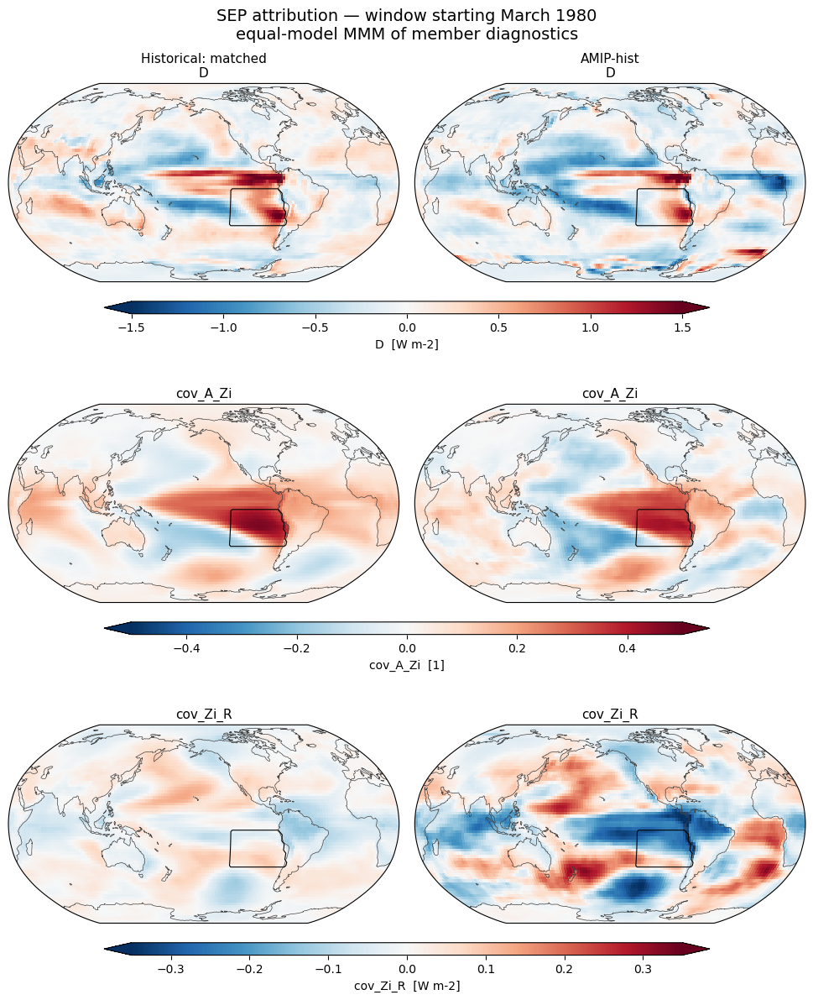

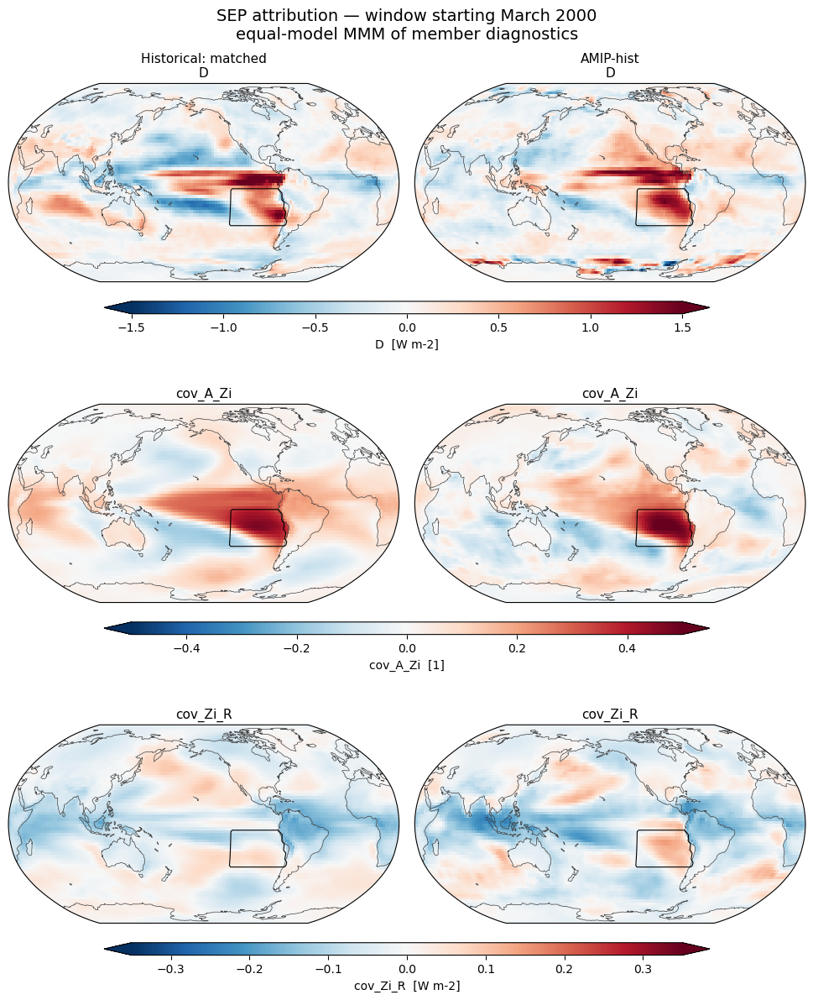

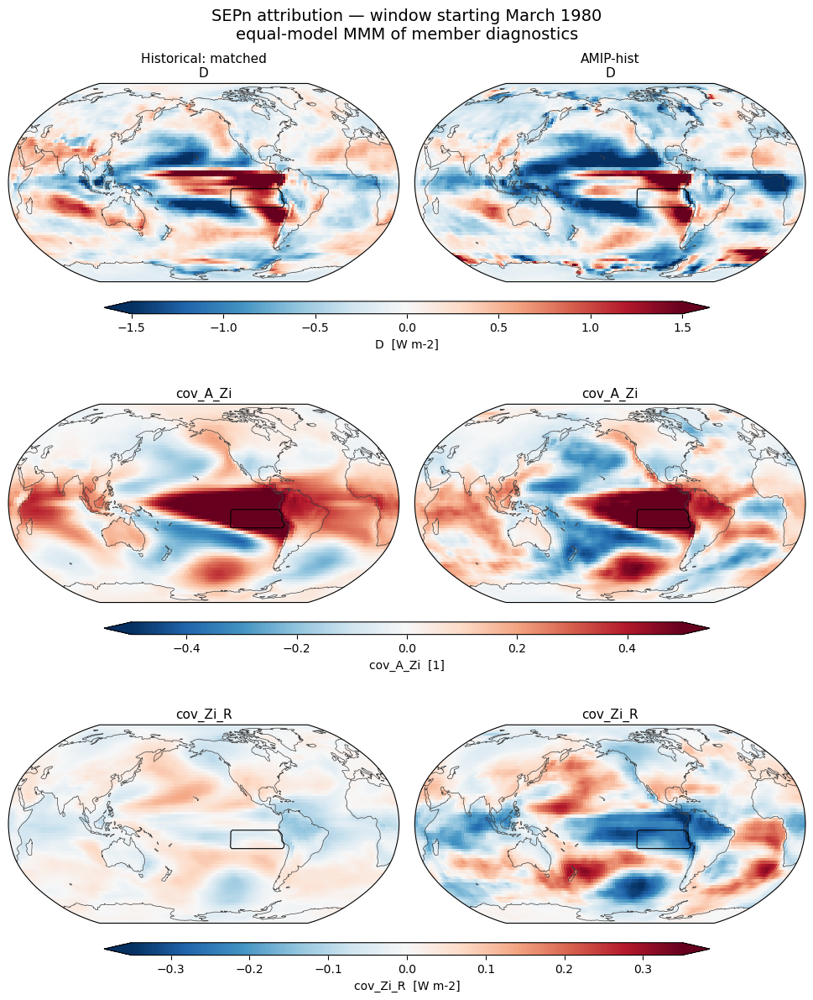

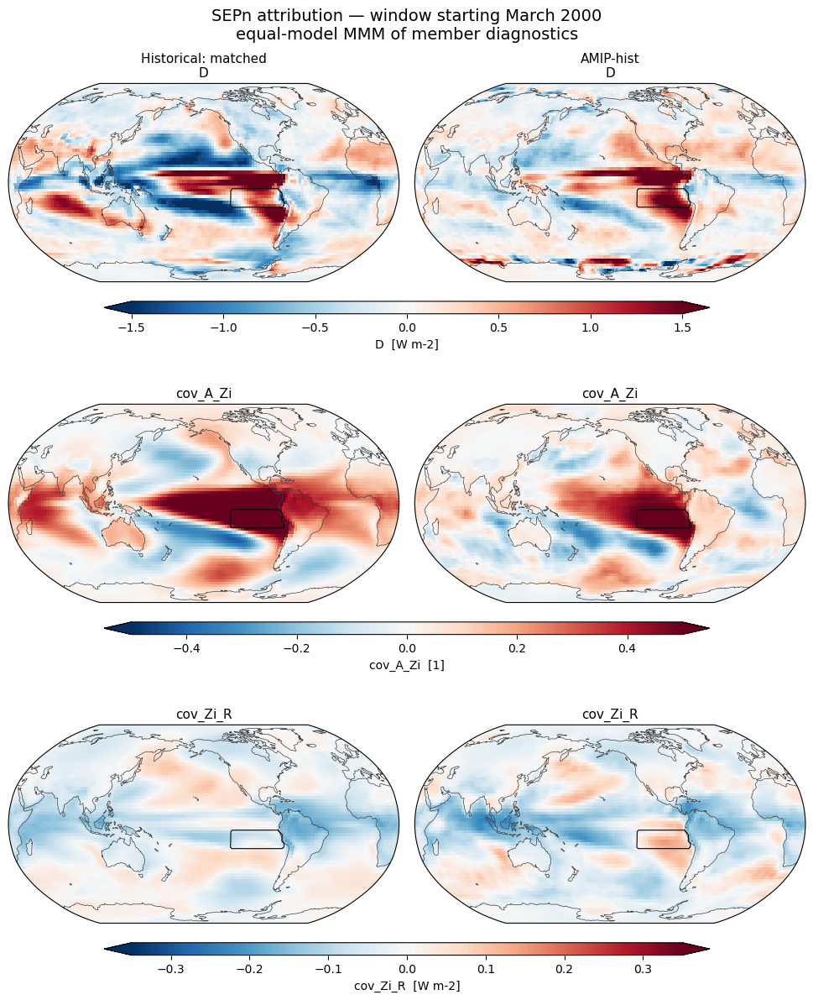

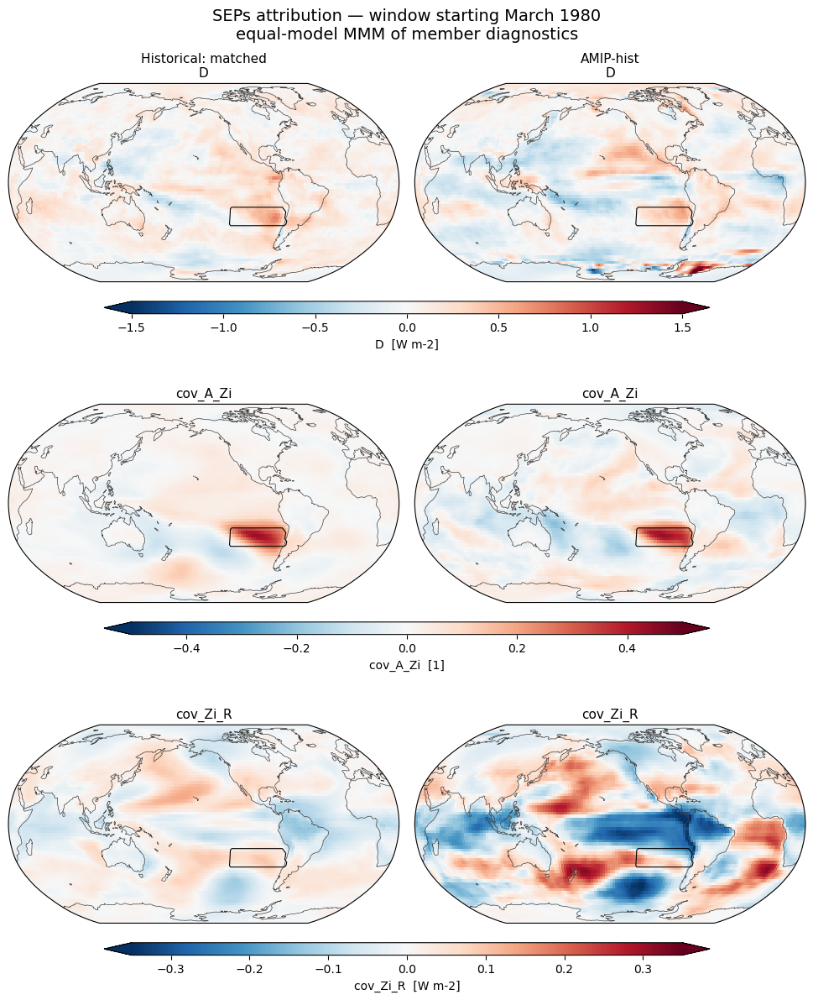

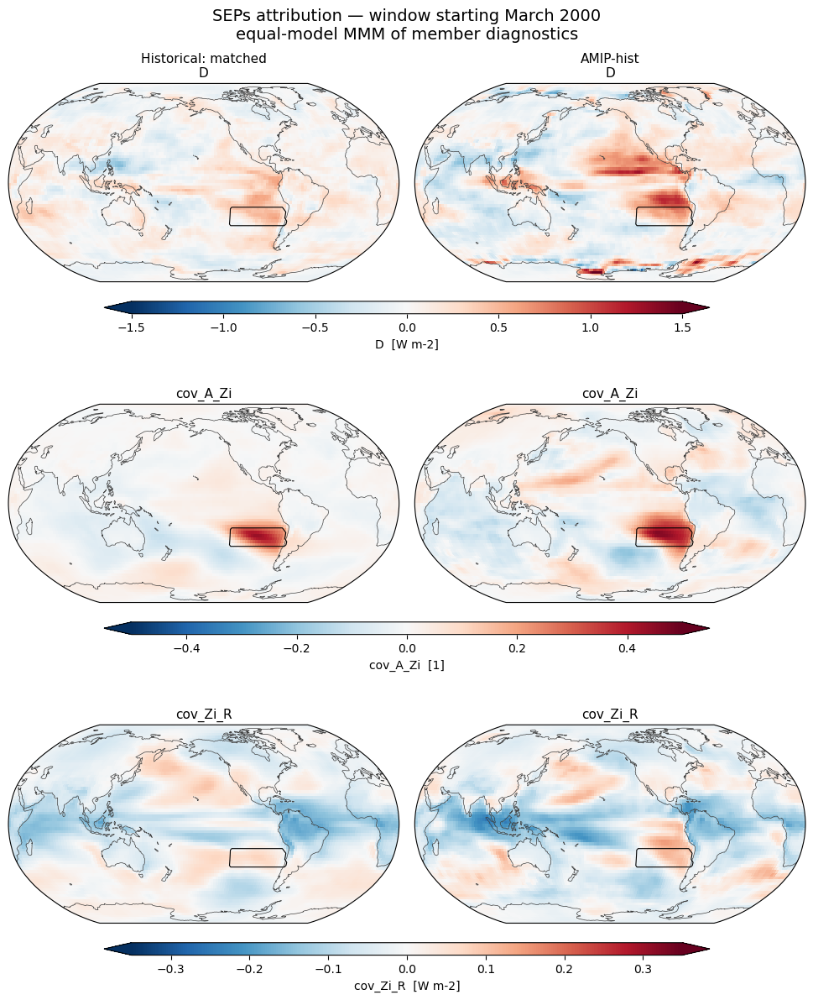

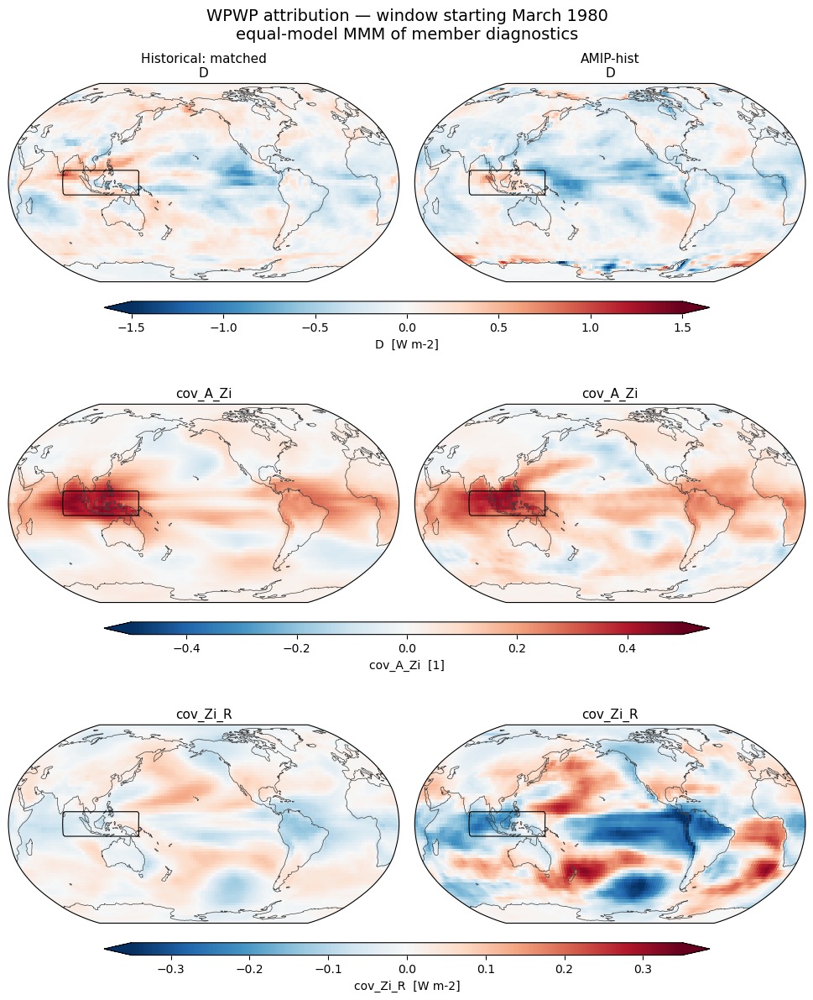

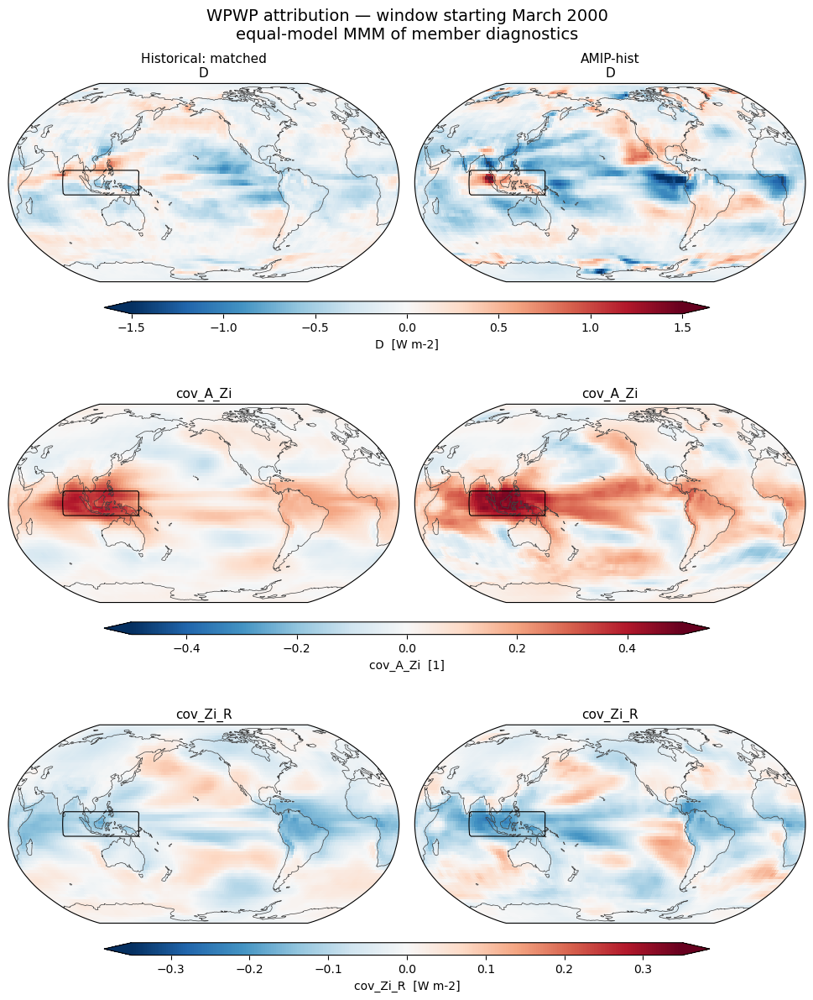

In [19]:
# %% 10. Your example years, now for all four source indices
# Identical limits across regions and years. cov_Zi_R is intentionally identical
# between source regions; the outline shows WHICH regional average defines I.
# D and cov_A_Zi DO depend on that source region.
for region in ra_region_names:
    for year in [1980, 2000]:
        filename = ra_run_dir/f"figures/{region}_running_{year}.png" if ra_save_figures else None
        fig, axes = plot_region_attr_maps(["D", "cov_A_Zi", "cov_Zi_R"], region=region,
            start_year=year, vlims=ra_plot_vlims, savepath=filename)
        plt.show()
        plt.close(fig)  # Jupyter retains the display; don't hold all large figures in memory.

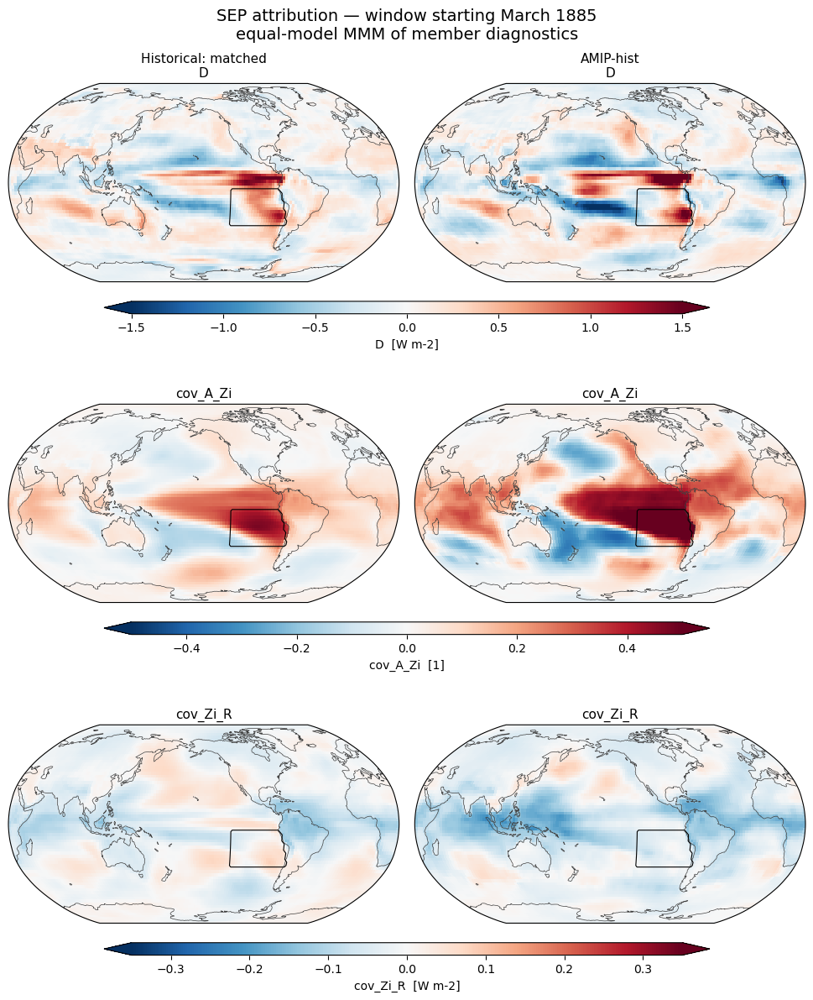

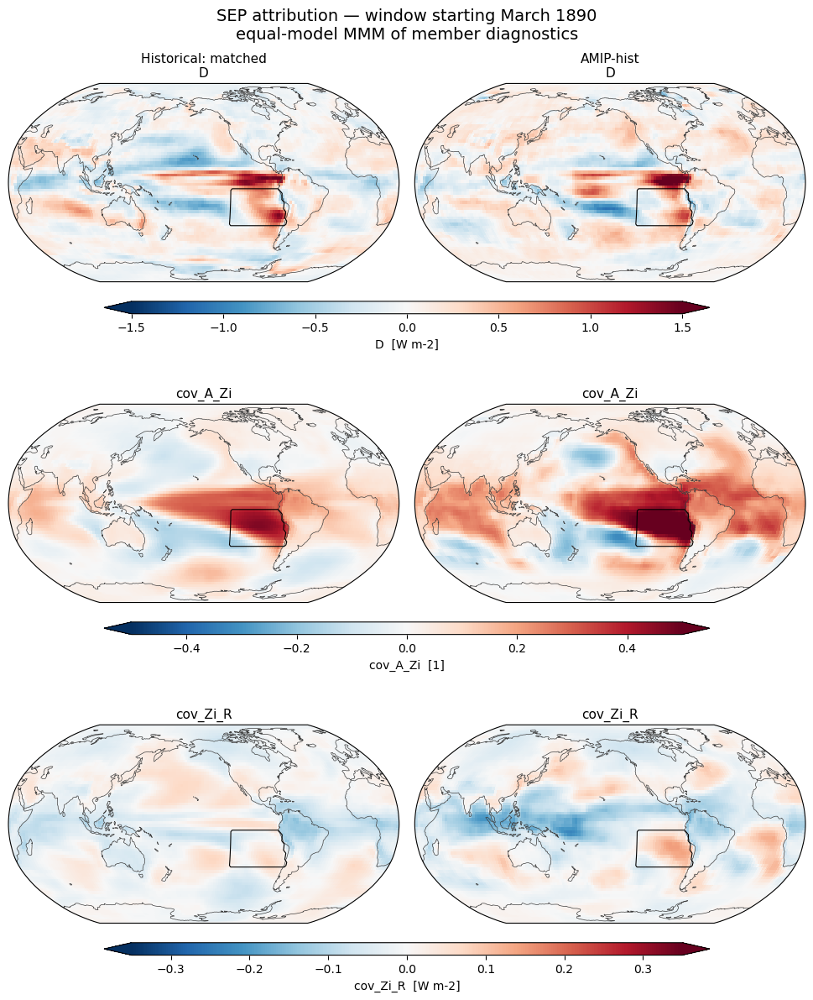

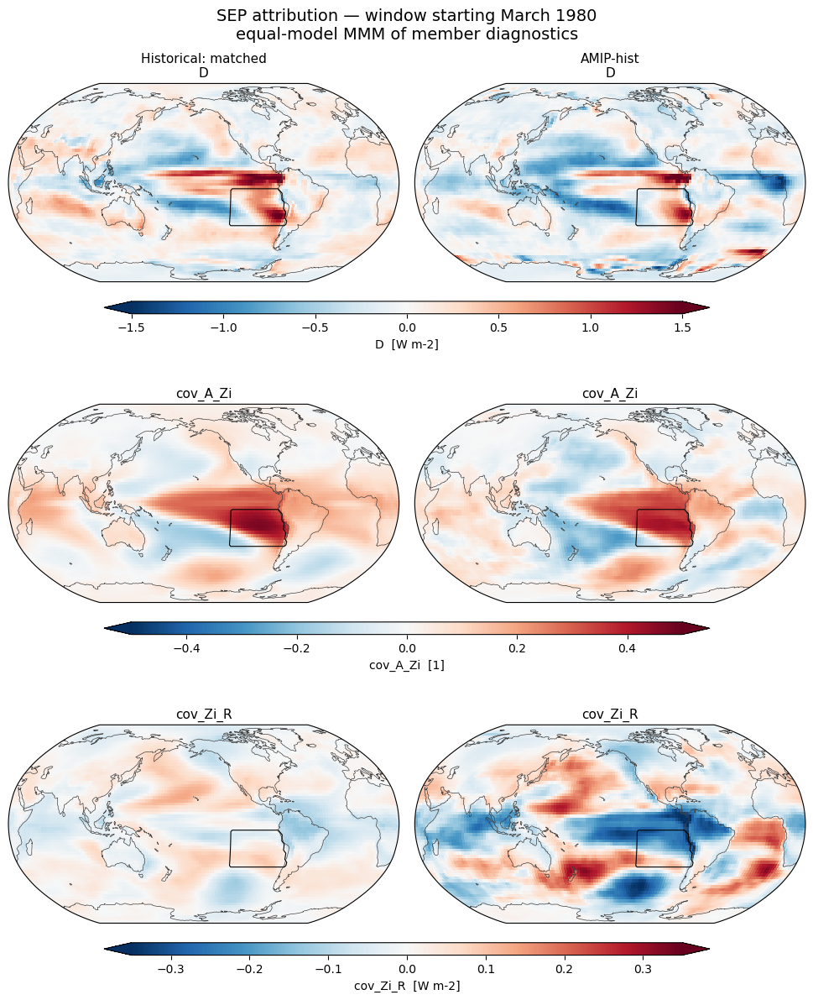

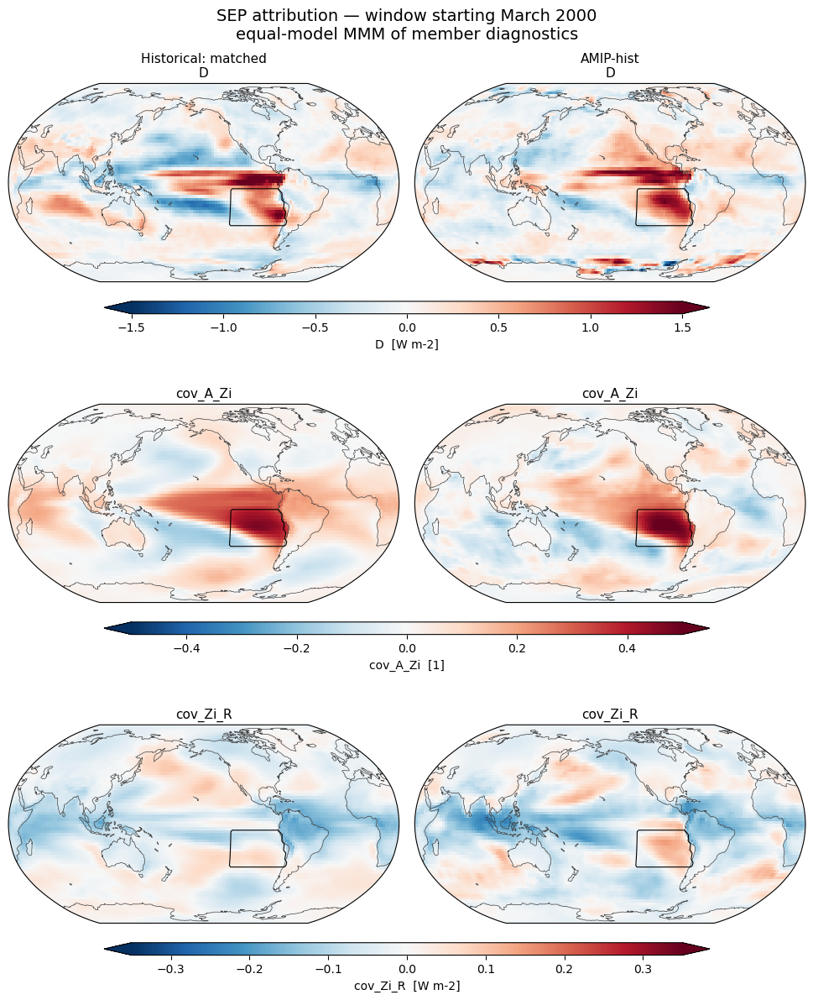

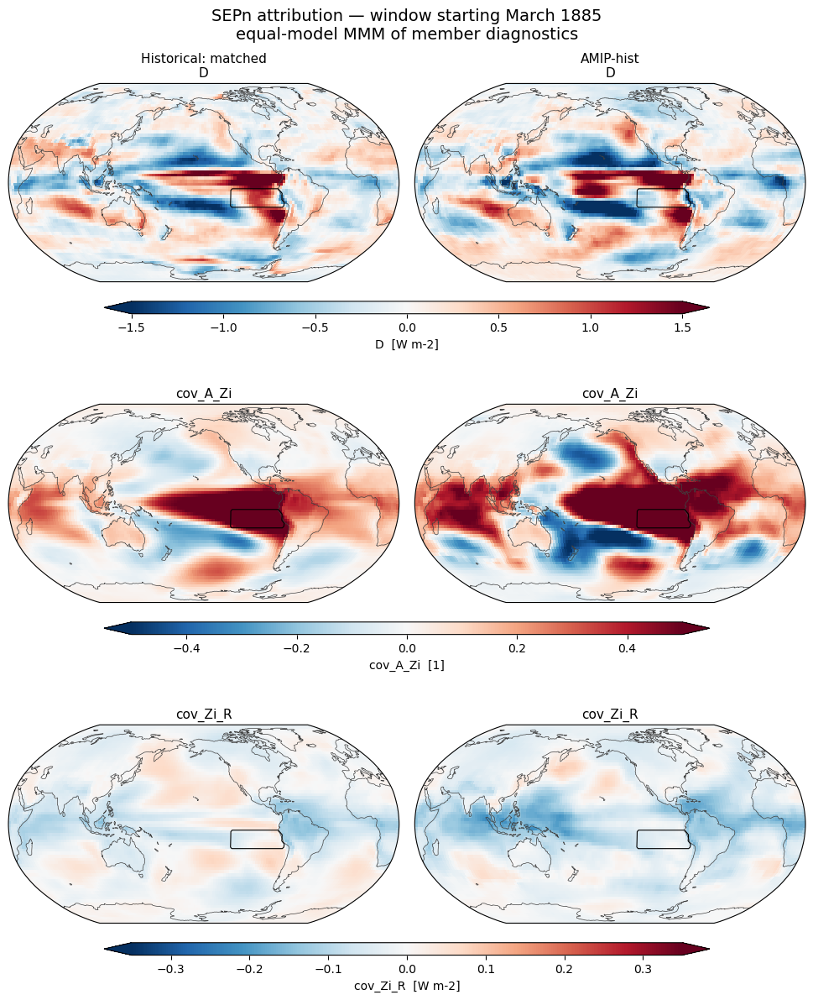

...

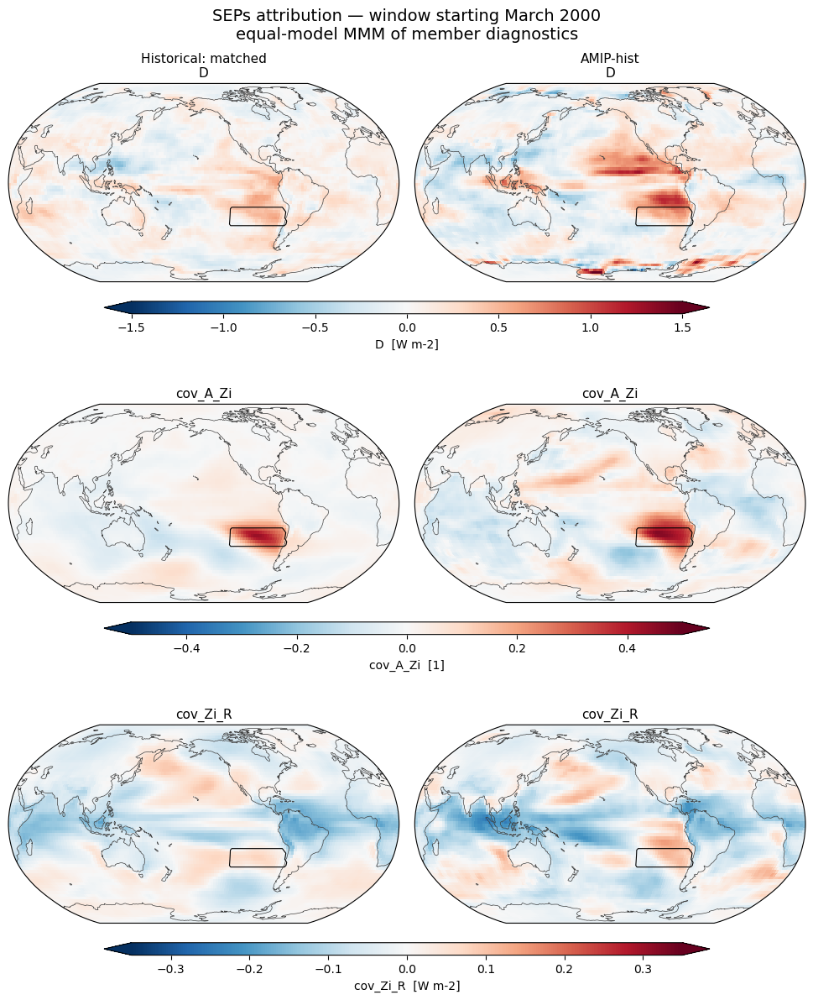

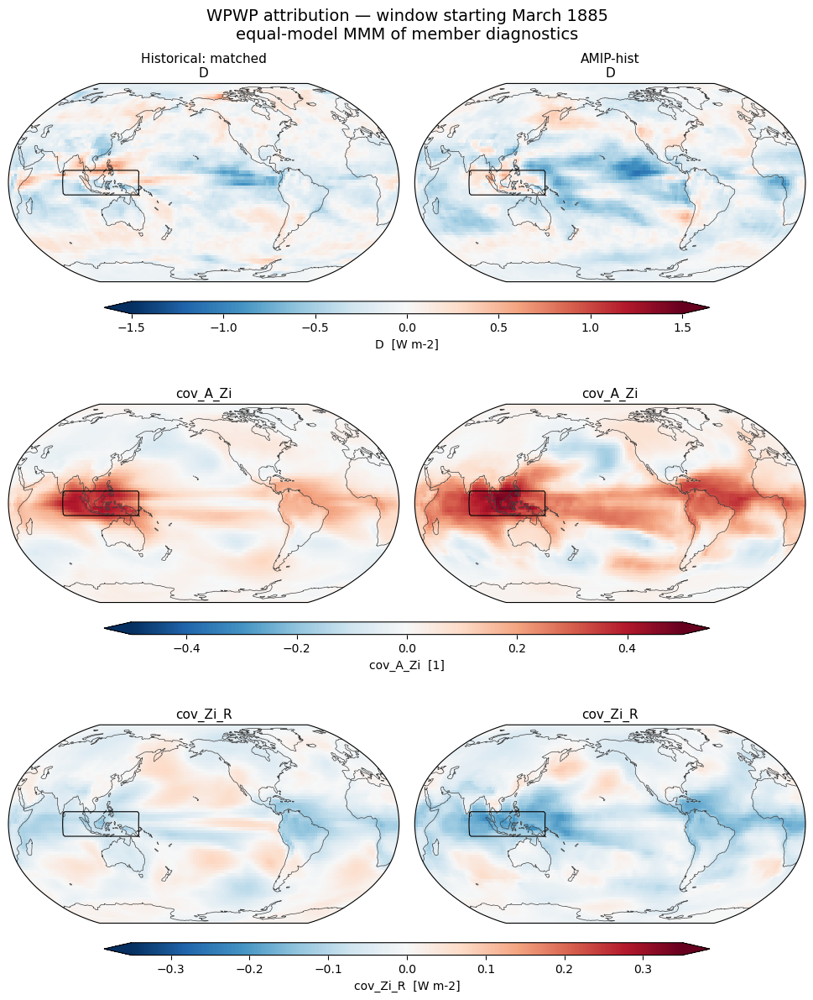

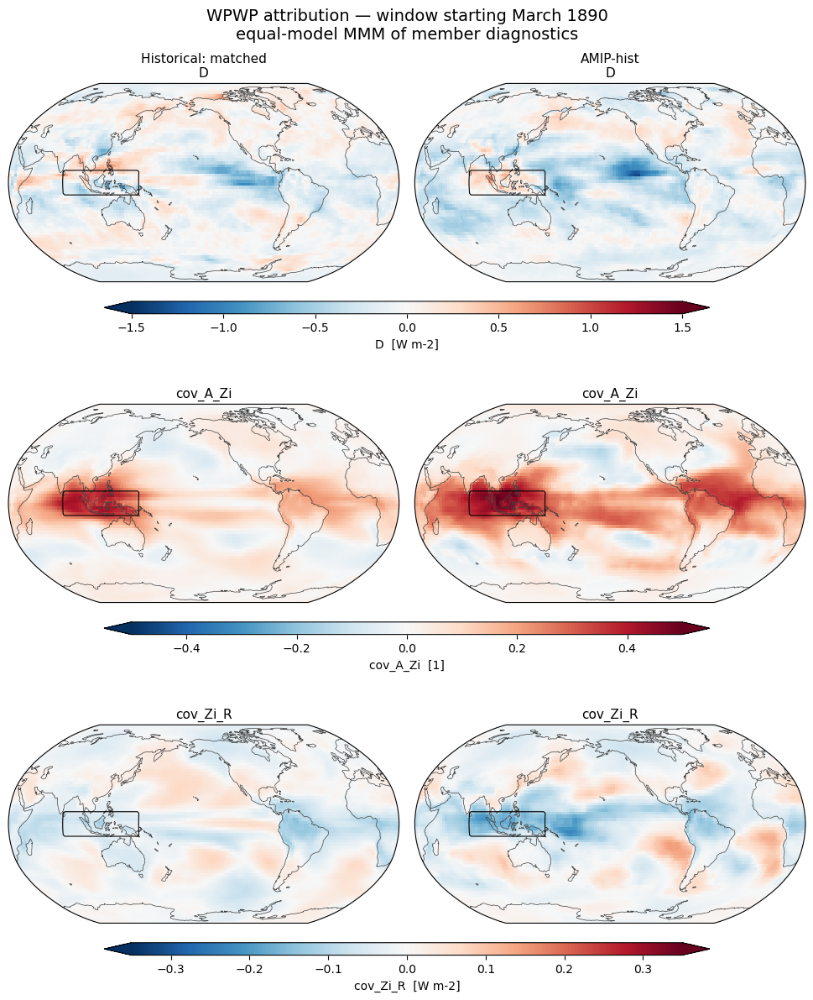

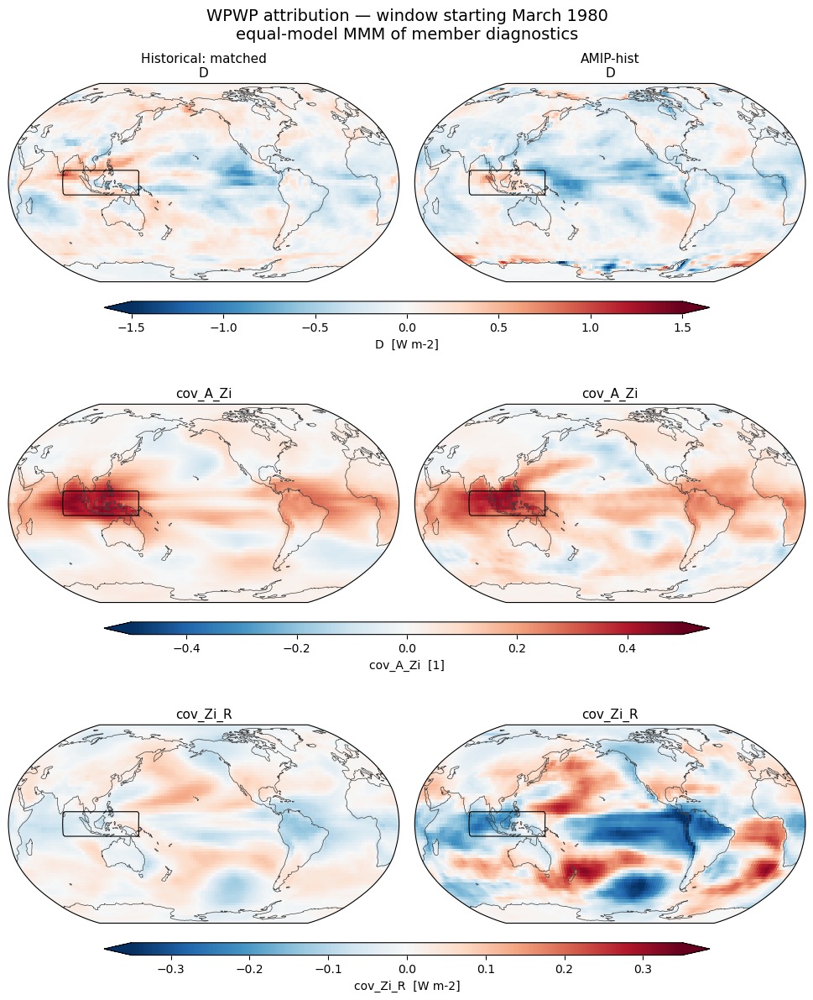

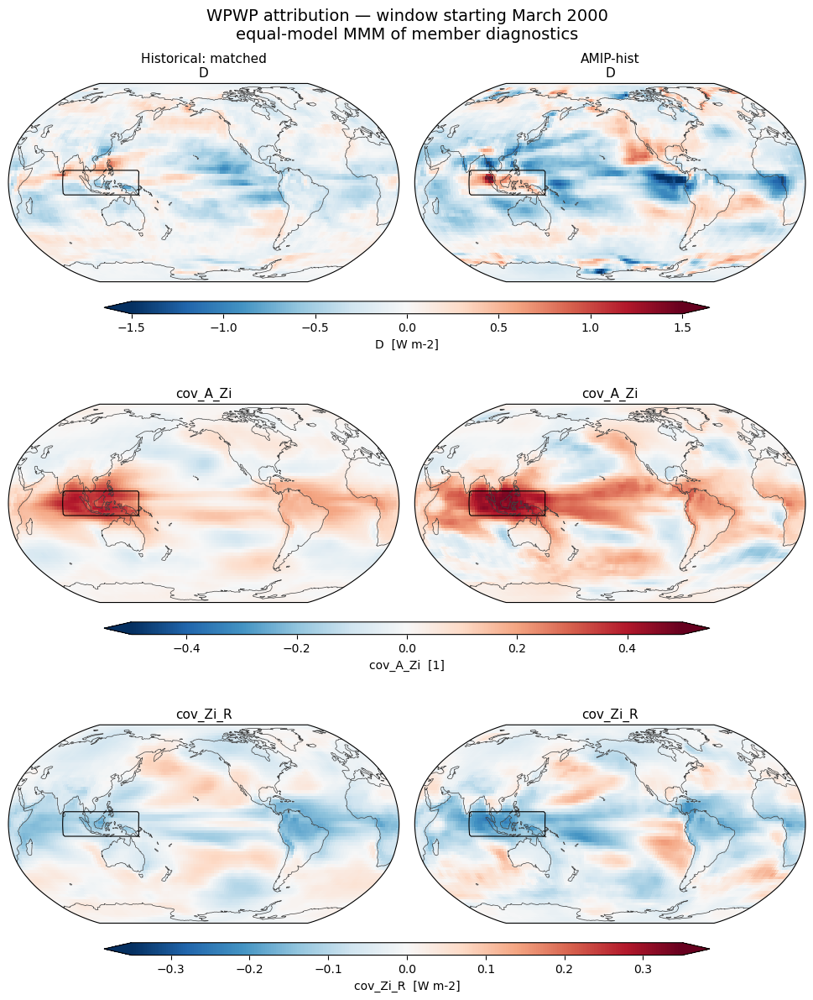

In [11]:
# %% 10. Your example years, now for all four source indices
# Identical limits across regions and years. cov_Zi_R is intentionally identical
# between source regions; the outline shows WHICH regional average defines I.
# D and cov_A_Zi DO depend on that source region.
for region in ra_region_names:
    for year in ra_plot_years:
        filename = ra_run_dir/f"figures/{region}_running_{year}.png" if ra_save_figures else None
        fig, axes = plot_region_attr_maps(["D", "cov_A_Zi", "cov_Zi_R"], region=region,
            start_year=year, vlims=ra_plot_vlims, savepath=filename)
        plt.show()
        plt.close(fig)  # Jupyter retains the display; don't hold all large figures in memory.

# Single custom plot, or a model/member instead of the MMM:
# fig, axes = plot_region_attr_maps(['D','cov_A_Zi','cov_Zi_R'], region='SEPs',
#     start_year=1975, model='TaiESM1', experiments=['amip_hist'], vlims=[1.5,.5,.2])




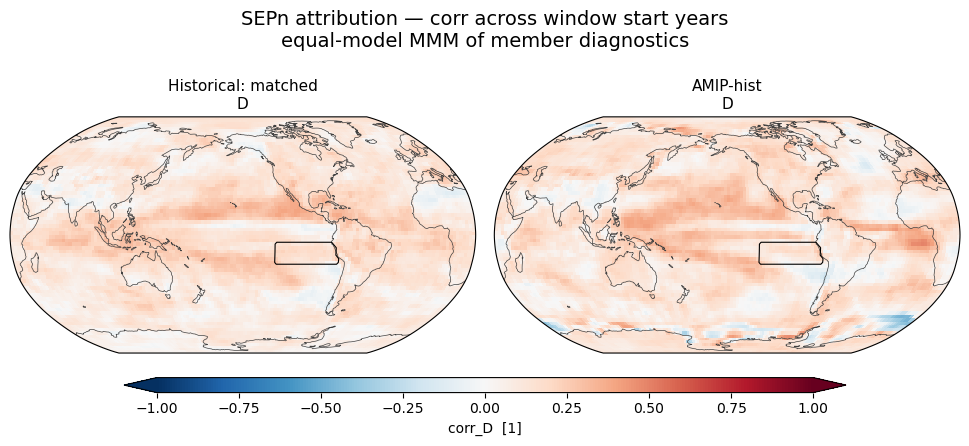

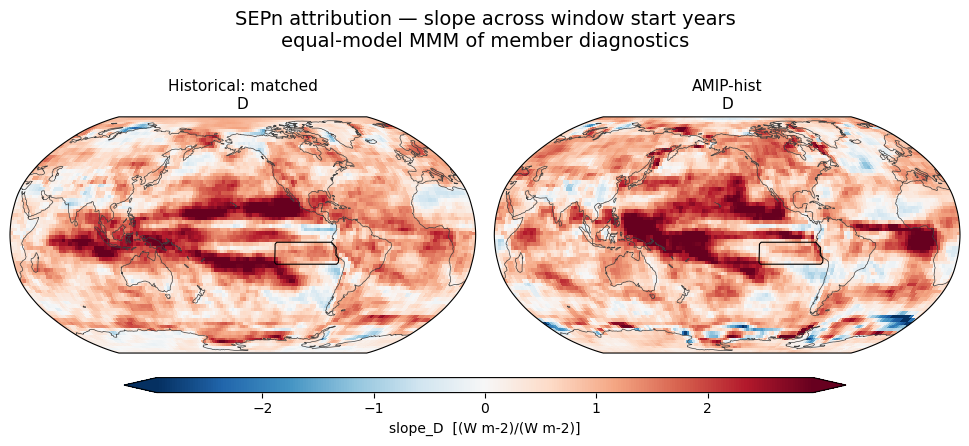

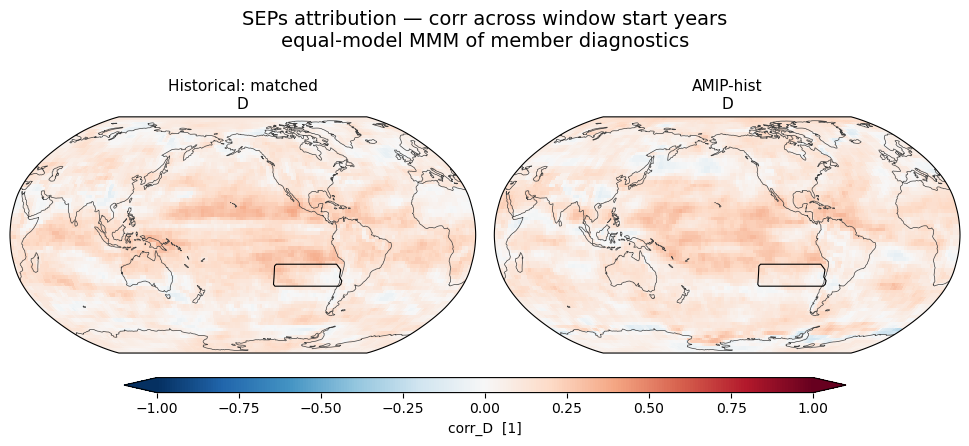

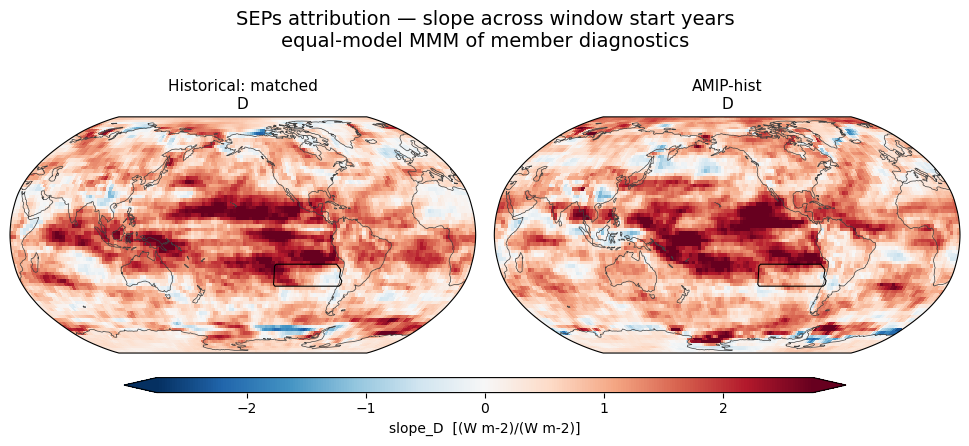

In [14]:
# %% 11. Across-window correlation/regression examples (change the selected region)
ra_fit_region = "SEPn"
for statistic in ["corr", "slope"]:
    filename = ra_run_dir/f"figures/{ra_fit_region}_{statistic}_D.png" if ra_save_figures else None
    fig, axes = plot_region_attr_maps(["D"], region=ra_fit_region, statistic=statistic, savepath=filename)
    plt.show()
    plt.close(fig)

# All old non-projection context fits are available. Each region's fits use ITS
# OWN member-wise I(s); these are not fits to model-mean or MMM time series.
# plot_region_attr_maps(['cov_A_Zi','cov_A_Qi','sigma_Ri'], region='SEPs', statistic='corr')
# plot_region_attr_maps(['D'], region='WPWP', statistic='slope_per_index_sd')

ra_fit_region = "SEPs"
for statistic in ["corr", "slope"]:
    filename = ra_run_dir/f"figures/{ra_fit_region}_{statistic}_D.png" if ra_save_figures else None
    fig, axes = plot_region_attr_maps(["D"], region=ra_fit_region, statistic=statistic, savepath=filename)
    plt.show()
    plt.close(fig)


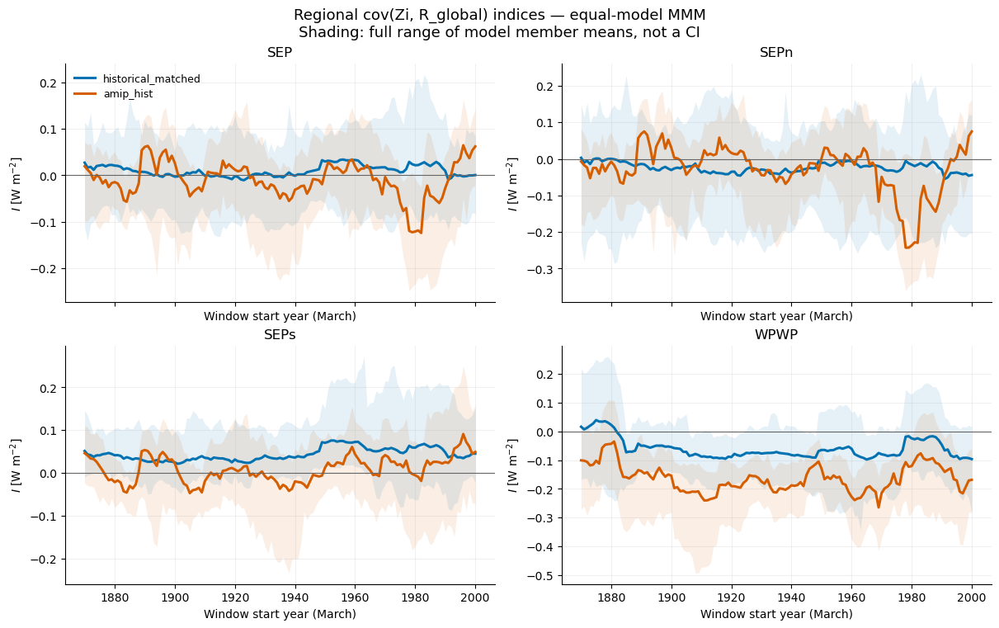

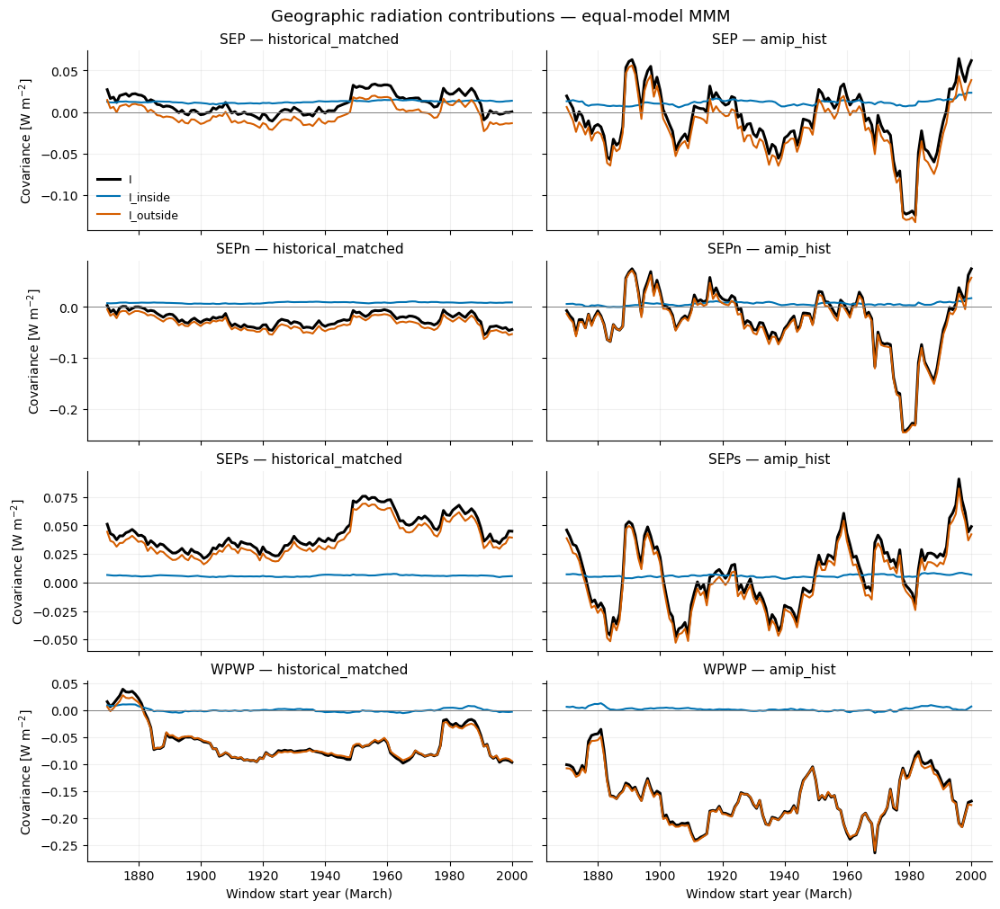

In [13]:
# %% 12. Compact index and geographic-budget plots, without loading full map files
def plot_region_indices(*, experiments=None, show_model_range=True, savepath=None):
    """Four regional MMM indices; optional full range of model MEMBER MEANS."""
    experiments = [e for e in ra_experiments if e in ra_catalog['model_names']] if experiments is None else list(experiments)
    colors = {'historical_matched': '#0072B2', 'amip_hist': '#D55E00', 'historical': '#009E73'}
    years = ra_catalog['coordinates']['start_year']
    fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True, layout='constrained')
    for ax, region in zip(axes.ravel(), ra_region_names):
        for experiment in experiments:
            series = ra_MMM_series[region][experiment]['I']
            if show_model_range:
                model_series = np.stack(list(ra_model_mean_series[region][experiment]['I'].values()))
                ax.fill_between(years, model_series.min(axis=0), model_series.max(axis=0), color=colors[experiment], alpha=.10, linewidth=0)
            ax.plot(years, series, color=colors[experiment], lw=2.2, label=experiment)
        ax.axhline(0, color='.4', lw=.8)
        ax.set(title=region, xlabel='Window start year (March)', ylabel=r'$I$ [W m$^{-2}$]')
        ax.grid(alpha=.18)
        ax.spines[['top', 'right']].set_visible(False)
    axes.ravel()[0].legend(frameon=False, fontsize=9)
    fig.suptitle('Regional cov(Zi, R_global) indices — equal-model MMM' + ('\nShading: full range of model member means, not a CI' if show_model_range else ''), fontsize=13)
    if savepath is not None:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=220, bbox_inches='tight')
    return fig, axes


def plot_region_budgets(*, experiments=None, keys=('I', 'I_inside', 'I_outside'), savepath=None):
    """Rows=source region, columns=experiment. MMMs of member-wise budgets."""
    experiments = [e for e in ra_experiments if e in ra_catalog['model_names']] if experiments is None else list(experiments)
    years = ra_catalog['coordinates']['start_year']
    colors = ['black', '#0072B2', '#D55E00', '#009E73', '#CC79A7']
    fig, axes = plt.subplots(len(ra_region_names), len(experiments), figsize=(5.5*len(experiments), 10),
                             sharex=True, sharey='row', squeeze=False, layout='constrained')
    for row, region in enumerate(ra_region_names):
        for col, experiment in enumerate(experiments):
            ax = axes[row, col]
            for i, key in enumerate(keys):
                ax.plot(years, ra_MMM_series[region][experiment][key], label=key, color=colors[i % len(colors)], lw=2.2 if key == 'I' else 1.5)
            ax.axhline(0, color='.5', lw=.7)
            ax.grid(alpha=.18)
            ax.spines[['top', 'right']].set_visible(False)
            ax.set_title(f'{region} — {experiment}', fontsize=11)
            if col == 0:
                ax.set_ylabel(r'Covariance [W m$^{-2}$]')
            if row == len(ra_region_names)-1:
                ax.set_xlabel('Window start year (March)')
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle('Geographic radiation contributions — equal-model MMM', fontsize=13)
    if savepath is not None:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=220, bbox_inches='tight')
    return fig, axes


fig, axes = plot_region_indices(savepath=ra_run_dir/'figures/regional_indices.png' if ra_save_figures else None)
plt.show()
fig, axes = plot_region_budgets(savepath=ra_run_dir/'figures/inside_outside_budgets.png' if ra_save_figures else None)
plt.show()
# To keep the receiving domain fixed as full SEP even for northern/southern A:
# plot_region_budgets(keys=('I','I_in_SEP','I_outside_SEP'))
# Or isolate within-region cross-cell contributions:
# plot_region_budgets(keys=('I_inside','I_diag','I_inside_cross'))


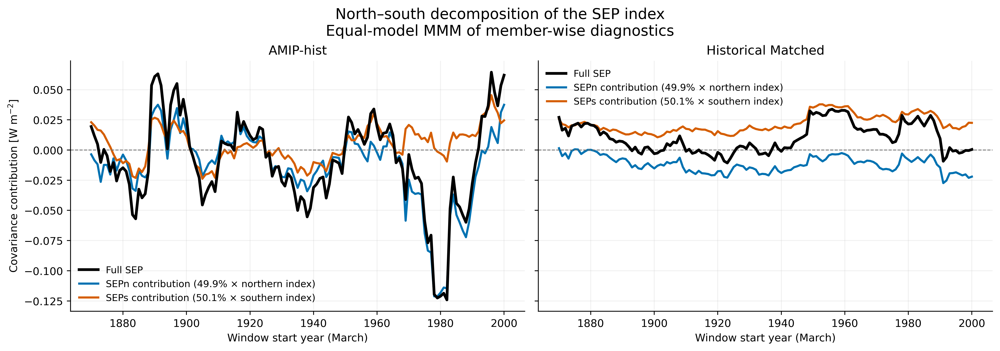

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use the loaded compact series: these are already member means, then equal-model MMMs.
historical_experiment = "historical_matched"    # Change to "historical" if calculated.
experiments = ["amip_hist", historical_experiment]
panel_titles = ["AMIP-hist", historical_experiment.replace("_", " ").title()]
years = np.asarray(ra_catalog["coordinates"]["start_year"])

# Latitude halves need not have equal areas. Use the saved fractions, not 0.5.
fractions = ra_catalog["SEP_area_fractions"]
f_north, f_south = fractions["SEPn"], fractions["SEPs"]
np.testing.assert_allclose(f_north + f_south, 1.)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True, layout="constrained",dpi=400)

# Plot each half's contribution to the FULL SEP index, rather than its unweighted index.
# The black curve should equal the blue plus orange curves at every start year.
for ax, experiment, title in zip(axes, experiments, panel_titles):
    total = np.asarray(ra_MMM_series["SEP"][experiment]["I"])
    north = f_north * np.asarray(ra_MMM_series["SEPn"][experiment]["I"])
    south = f_south * np.asarray(ra_MMM_series["SEPs"][experiment]["I"])

    np.testing.assert_allclose(total, north + south, rtol=1e-8, atol=1e-10,
                               err_msg=f"{experiment}: north/south contributions do not reconstruct SEP")

    ax.plot(years, total, color="black", lw=2.6, label="Full SEP", zorder=3)
    ax.plot(years, north, color="#0072B2", lw=2,
            label=f"SEPn contribution ({f_north:.1%} × northern index)")
    ax.plot(years, south, color="#D55E00", lw=2,
            label=f"SEPs contribution ({f_south:.1%} × southern index)")

    ax.axhline(0, color="0.45", lw=0.8, linestyle="--")
    ax.set(title=title, xlabel="Window start year (March)")
    ax.grid(alpha=0.18)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=9)

axes[0].set_ylabel(r"Covariance contribution [W m$^{-2}$]")
fig.suptitle("North–south decomposition of the SEP index\nEqual-model MMM of member-wise diagnostics", fontsize=14)

# Optional save; choose a path to enable.
savepath = None  # ra_run_dir / "figures/SEP_north_south_decomposition.png"
if savepath is not None:
    savepath = Path(savepath)
    savepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(savepath, dpi=220, bbox_inches="tight")

plt.show()

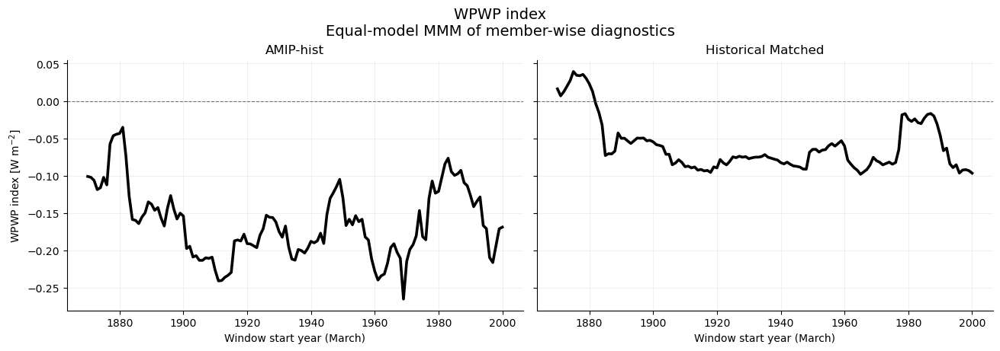

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Match the experiments and figure dimensions used for the SEP decomposition.
historical_experiment = "historical_matched"    # Or "historical" if calculated.
experiments = ["amip_hist", historical_experiment]
panel_titles = ["AMIP-hist", historical_experiment.replace("_", " ").title()]
years = np.asarray(ra_catalog["coordinates"]["start_year"])

fig_wpwp, axes_wpwp = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True,
                                   layout="constrained")

# These are already means across members within models, then equal-model MMMs.
for ax, experiment, title in zip(axes_wpwp, experiments, panel_titles):
    index = np.asarray(ra_MMM_series["WPWP"][experiment]["I"])
    ax.plot(years, index, color="black", lw=2.6)
    ax.axhline(0, color="0.45", lw=0.8, linestyle="--")
    ax.set(title=title, xlabel="Window start year (March)")
    ax.grid(alpha=0.18)
    ax.spines[["top", "right"]].set_visible(False)

axes_wpwp[0].set_ylabel(r"WPWP index [W m$^{-2}$]")
fig_wpwp.suptitle("WPWP index\nEqual-model MMM of member-wise diagnostics", fontsize=14)

# Optional: specify the same y-limits as your SEP figure for direct visual comparison.
# axes_wpwp[0].set_ylim(-0.2, 0.2)   # Shared with the right panel.

savepath_wpwp = None  # ra_run_dir / "figures/WPWP_indices.png"
if savepath_wpwp is not None:
    savepath_wpwp = Path(savepath_wpwp)
    savepath_wpwp.parent.mkdir(parents=True, exist_ok=True)
    fig_wpwp.savefig(savepath_wpwp, dpi=220, bbox_inches="tight")

plt.show()